## Part 1: Choose an Industry Problem

**Industry:** Education — Higher Education

**Intended User:** College student success coordinator or academic advisor

**Main Problem:**
The college wants to identify patterns associated with student dropout and academic success so that students who may need additional support can be recognized earlier.

**Why the Problem Matters:**
Students may leave college or struggle academically because of a combination of academic, financial, enrollment, and personal circumstances. When colleges understand which factors are associated with dropout and graduation, student success staff can provide advising, tutoring, financial guidance, academic planning, or other support before a student falls too far behind.

Improving student retention also benefits the institution by helping more students complete their education and by allowing limited support resources to be directed toward students and groups with the greatest needs.

**Decision the Assistant Supports:**
The statistical assistant will help a college student success coordinator determine which student characteristics and academic patterns are associated with dropout or graduation. The results can support decisions about which student groups may need additional outreach, advising, or academic assistance.

**Connected Project Focus:**
All six agent skills will support the same overall problem of understanding college student success and dropout risk. The skills will explore the student population, compare meaningful student groups, examine factors associated with academic outcomes, and identify patterns that may help student success staff make informed support decisions.

The assistant will not make final decisions about individual students. Its results will be used as supporting information alongside professional judgment and direct communication with students.


# Part 2: Select One Dataset

## Dataset Name

**Predict Students’ Dropout and Academic Success**

## Dataset Source

The dataset is publicly available from the **University of California, Irvine Machine Learning Repository**, also known as the UCI Machine Learning Repository.

The dataset was created using student records from a higher-education institution. It was designed to examine factors associated with college dropout, continued enrollment, and graduation.

The dataset is appropriate for this project because it focuses on higher education and directly connects to the selected industry problem of understanding student success and identifying groups that may need additional academic or financial support.

## What One Row Represents

Each row represents **one college student**.

Each student record contains information related to:

* Academic background
* College enrollment
* Admission performance
* Financial circumstances
* First-semester academic performance
* Second-semester academic performance
* Final academic outcome

The dataset does not contain student names or other direct personal identifiers.

## Number of Observations

The dataset contains **4,424 observations**.

This means the dataset contains records for 4,424 college students.

The number of observations was confirmed in R using:

```r
dim(students)
```

The result showed:

```text
4424 37
```

## Number of Variables

The dataset contains **37 total variables**.

These include:

* 36 predictor variables
* 1 outcome variable

The dataset includes numeric, binary, categorical, and coded variables.

## Main Variables

The main variables that may be used in this project include:

* `age_at_enrollment`
* `admission_grade`
* `previous_qualification_grade`
* `course`
* `daytime_evening_attendance`
* `scholarship_holder`
* `debtor`
* `tuition_fees_up_to_date`
* `curricular_units_1st_sem_enrolled`
* `curricular_units_1st_sem_approved`
* `curricular_units_1st_sem_grade`
* `curricular_units_1st_sem_without_evaluations`
* `curricular_units_2nd_sem_enrolled`
* `curricular_units_2nd_sem_approved`
* `curricular_units_2nd_sem_grade`
* `curricular_units_2nd_sem_without_evaluations`
* `target`

These variables can help examine academic performance, financial barriers, course progress, enrollment characteristics, and final student outcomes.

## Outcome Variable

The main outcome variable is `target`.

It contains three possible student outcomes:

* `Dropout`
* `Enrolled`
* `Graduate`

The outcome counts were confirmed in R using:

```r
table(students$target)
```

The results were:

* **Dropout:** 1,421 students
* **Enrolled:** 794 students
* **Graduate:** 2,209 students

The `Graduate` group is the largest outcome group, while the `Enrolled` group is the smallest.

The original three categories will be preserved for descriptive analyses and visualizations.

For statistical methods that require only two groups, a separate version of the data may compare students who dropped out with students who graduated. Students classified as enrolled would only be excluded from that specific analysis, and the exclusion would be clearly explained.

## Missing-Data Issues

The missing-data check showed that the dataset contains **no missing values**.

The following code was used:

```r
colSums(is.na(students))
```

Every variable returned a value of `0`, meaning no missing values were detected.

This is helpful because observations will not need to be removed or replaced because of missing information.

Even though no missing values were found, the project will continue to check for missing information after any new variables are created.

## Duplicate Records

The dataset was checked for completely duplicated rows using:

```r
sum(duplicated(students))
```

The result was:

```text
0
```

This means the dataset contains **no completely duplicated student records**.

## Data-Quality Issues

Although the dataset does not contain missing values or duplicate rows, several data-quality and interpretation issues must still be considered.

### Coded Categorical Variables

Many categorical variables are stored as numbers.

For example, variables such as:

* `debtor`
* `scholarship_holder`
* `tuition_fees_up_to_date`
* `gender`
* `international`
* `displaced`

may use values such as `0` and `1` to represent categories.

These variables will need to be converted into readable labels such as `Yes` and `No` before they are presented in tables or graphs.

### Course Codes

The `course` variable uses numeric codes to represent different academic programs.

The numbers should not be treated as meaningful quantities. They represent categories rather than higher or lower course values.

The course codes may need to be converted into descriptive labels later in the project.

### Unequal Outcome Groups

The three outcome groups are not equal in size.

There are:

* 1,421 students in the Dropout group
* 794 students in the Enrolled group
* 2,209 students in the Graduate group

Because the groups are unequal, the project should report both counts and percentages.

For statistical modeling, overall accuracy should not be the only measure used because a model could perform well for the largest group but poorly for the smaller groups.

### Many Possible Predictor Variables

The dataset contains 36 predictor variables.

Using all predictors in one statistical model could make the model difficult to understand and explain.

The project will select a smaller number of variables that are directly connected to student retention, academic progress, and financial barriers.

### Data From One Institution

The dataset comes from one higher-education institution.

The findings may not apply to every college or university because institutions may differ in:

* Student populations
* Academic programs
* Admission standards
* Tuition systems
* Financial-aid systems
* Student support services

The results should therefore be interpreted as patterns within this dataset rather than universal conclusions about all college students.

### Observational Data

The dataset is observational.

This means it can identify statistical relationships, but it cannot prove that one variable directly caused a student to drop out or graduate.

For example, students whose tuition fees are not current may have a higher dropout rate. However, this would not prove that tuition status was the only cause of dropout.

Other academic, personal, institutional, or financial circumstances may also affect the outcome.

### Responsible Use

Variables such as age, gender, nationality, or family background should not be used alone to label an individual student as likely to fail.

The statistical assistant should help student-success staff recognize broad patterns and decide where supportive outreach may be useful.

It should not make automatic decisions about admissions, financial aid, enrollment, or access to services.

## Data Preparation Completed in R

The following basic preparation was completed in R:

1. The dataset was imported.
2. The semicolon delimiter was specified.
3. Column names were cleaned and standardized.
4. The number of observations and variables was confirmed.
5. Missing values were checked.
6. Duplicate rows were checked.
7. The outcome categories were reviewed.

The dataset originally used semicolons to separate columns. When it was first imported with a comma-based function, R read the entire dataset as one column.

The problem was corrected by using `read_delim()` with `delim = ";"`.







In [1]:
install.packages("janitor")
library(tidyverse)
library(janitor)

students <- read_delim(
  "data.csv",
  delim = ";",
  show_col_types = FALSE
) |>
  clean_names()


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘snakecase’


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test




In [2]:
# Check missing values
colSums(is.na(students))

marital_status 
                                           0 
                            application_mode 
                                           0 
                           application_order 
                                           0 
                                      course 
                                           0 
                  daytime_evening_attendance 
                                           0 
                      previous_qualification 
                                           0 
                previous_qualification_grade 
                                           0 
                                 nacionality 
                                           0 
                       mothers_qualification 
                                           0 
                       fathers_qualification 
                                           0 
                          mothers_occupation 
                                           0 
                          fathers_occupation 
                                           0 
                             admission_grade 
                                           0 
                                   displaced 
                                           0 
                   educational_special_needs 
                                           0 
                                      debtor 
                                           0 
                     tuition_fees_up_to_date 
                                           0 
                                      gender 
                                           0 
                          scholarship_holder 
                                           0 
                           age_at_enrollment 
                                           0 
                               international 
                                           0 
           curricular_units_1st_sem_credited 
                                           0 
           curricular_units_1st_sem_enrolled 
                                           0 
        curricular_units_1st_sem_evaluations 
                                           0 
           curricular_units_1st_sem_approved 
                                           0 
              curricular_units_1st_sem_grade 
                                           0 
curricular_units_1st_sem_without_evaluations 
                                           0 
           curricular_units_2nd_sem_credited 
                                           0 
           curricular_units_2nd_sem_enrolled 
                                           0 
        curricular_units_2nd_sem_evaluations 
                                           0 
           curricular_units_2nd_sem_approved 
                                           0 
              curricular_units_2nd_sem_grade 
                                           0 
curricular_units_2nd_sem_without_evaluations 
                                           0 
                           unemployment_rate 
                                           0 
                              inflation_rate 
                                           0 
                                         gdp 
                                           0 
                                      target 
                                           0

In [3]:
# Check duplicate rows
sum(duplicated(students))

[1] 0

In [4]:

# Review outcome categories
table(students$target)


 Dropout Enrolled Graduate 
    1421      794     2209 

## Results of the Data Check

The R code produced the following results:

* **Observations:** 4,424
* **Variables:** 37
* **Missing values:** 0
* **Duplicate rows:** 0
* **Dropout students:** 1,421
* **Enrolled students:** 794
* **Graduate students:** 2,209

These results confirm that the dataset was imported correctly and is ready to support the planned statistical analyses.

## Confirmation That the Dataset Supports the Six Skills

The dataset can support the three required skills and three student-designed skills while keeping every analysis connected to student success and retention.

### Skill 1: Explore Data

The assistant can describe the overall student population and summarize variables such as:

* Student outcome counts and percentages
* Age at enrollment
* Admission grades
* Scholarship participation
* Tuition-payment status
* Debt status
* First-semester grades
* Courses enrolled
* Courses approved

Possible outputs include:

* Summary tables
* Frequency tables
* Bar charts
* Histograms
* Percentages
* Measures of center and spread

This skill will help a student success coordinator understand the general characteristics of the students in the dataset.

### Skill 2: Compare Two Groups

The assistant can compare two meaningful groups connected to student retention.

A possible question is:

**Do dropout rates differ between students whose tuition fees are up to date and students whose tuition fees are not up to date?**

This comparison is useful because financial circumstances may be connected to student persistence.

Other possible comparisons include:

* Scholarship holders versus students without scholarships
* Students with debt versus students without debt
* Daytime students versus evening students

The analysis may use:

* Counts and percentages
* A grouped bar chart
* A two-proportion test
* A chi-square test
* A confidence interval

### Skill 3: Use a Statistical Model

The project can use a logistic regression model to examine factors associated with dropout.

For a two-outcome model, the project may compare students who dropped out with students who graduated.

Possible predictors include:

* First-semester grade
* First-semester courses approved
* Tuition-fee status
* Debt status
* Scholarship status
* Admission grade
* Age at enrollment

The model can help identify which factors are statistically associated with a greater or lower probability of dropout.

The model will not be treated as a perfect prediction tool. It will be used to understand general patterns and support student outreach.

### Skill 4: Analyze First-Semester Academic Progress

This student-designed skill can examine how first-semester performance differs among students who:

* Dropped out
* Remained enrolled
* Graduated

The assistant may analyze:

* First-semester grades
* Courses enrolled
* Courses approved
* Number of evaluations
* Courses without evaluations

This skill supports early intervention because first-semester academic patterns may help identify groups experiencing difficulty.

### Skill 5: Examine Financial Barriers

This student-designed skill can examine student outcomes based on:

* Tuition-payment status
* Debt status
* Scholarship status

Possible outputs include:

* Outcome percentages
* Contingency tables
* Grouped bar charts
* Statistical association tests
* Practical interpretations

This skill may help student success staff understand whether certain financial groups experience different dropout or graduation patterns.

### Skill 6: Compare Outcomes Across Programs or Attendance Types

This student-designed skill can compare student outcomes across:

* Academic programs
* Daytime and evening attendance

The assistant can identify programs or attendance groups with different dropout, enrolled, or graduation percentages.

The result may help the institution determine where additional advising, tutoring, scheduling assistance, or further investigation may be useful.

The assistant must explain that differences between programs do not prove that a program itself causes students to drop out. Programs may serve students with different academic, financial, and scheduling circumstances.

## Final Dataset Decision

The **Predict Students’ Dropout and Academic Success** dataset will be used for the Industry Statistical Assistant project.

The dataset is appropriate because it:

* Is publicly available
* Does not contain direct student identifiers
* Contains 4,424 student records
* Contains 37 variables
* Has no missing values
* Has no completely duplicated records
* Includes a clear student outcome variable
* Supports descriptive statistical analysis
* Supports a comparison between two groups
* Supports a statistical model
* Supports three additional connected skills
* Matches the higher-education student-retention problem
* Supports the needs of a college student success coordinator

The dataset provides enough information to build six connected agent skills without making the project unnecessarily complicated.


# Part 3: Use Google Antigravity

Google Antigravity will be used as a development assistant throughout the Industry Statistical Assistant project.

The purpose of using Antigravity is to help organize, create, test, and improve the project. However, I remain responsible for reviewing and understanding everything included in the final submission.

## How Google Antigravity Will Be Used

Google Antigravity may be used to help with the following project tasks:

* Create the GitHub repository structure
* Create folders for the six agent skills
* Draft and revise the six `SKILL.md` files
* Create and improve R functions
* Identify and correct R coding errors
* Identify and correct Quarto rendering errors
* Review the statistical methods and their assumptions
* Create validation rules for inappropriate or invalid requests
* Draft and revise sections of the Quarto report
* Improve the README file
* Review the final repository for missing requirements

Google Antigravity will not replace my responsibility to understand the project.

## Planned Repository Structure

Antigravity may help create a repository structure similar to the following:

```text
student-success-statistical-assistant/
│
├── README.md
├── data/
│   └── data.csv
│
├── R/
│   ├── data_preparation.R
│   ├── explore_data.R
│   ├── compare_groups.R
│   ├── statistical_model.R
│   ├── academic_progress.R
│   ├── financial_barriers.R
│   └── program_outcomes.R
│
├── skills/
│   ├── explore-data/
│   │   └── SKILL.md
│   │
│   ├── compare-two-groups/
│   │   └── SKILL.md
│   │
│   ├── use-statistical-model/
│   │   └── SKILL.md
│   │
│   ├── analyze-academic-progress/
│   │   └── SKILL.md
│   │
│   ├── examine-financial-barriers/
│   │   └── SKILL.md
│   │
│   └── compare-program-outcomes/
│       └── SKILL.md
│
├── report/
│   └── final_report.qmd
│
└── output/
    ├── figures/
    └── tables/
```

The exact folder names may change as the project develops, but the repository will remain organized so that the dataset, R code, agent skills, report, figures, and documentation are easy to locate.

## Planned Antigravity Workflow

For each project task, I will provide Antigravity with a clear request.

For example, I may ask Antigravity to:

```text
Create a SKILL.md file for an Explore Data skill.

The skill should work with a college student success dataset.
It should summarize student outcomes, admission grades, age at enrollment,
scholarship status, and tuition-payment status.

The skill must validate that the requested variable exists and that the
requested summary is appropriate for the variable type.

Do not invent results. The skill should direct R to perform the analysis.
```

Antigravity may then create or revise the file. I will review the result before accepting it.

## Review and Testing Responsibilities

After Antigravity creates or changes a file, I will:

1. Read the generated content.
2. Confirm that it relates to the selected student-retention problem.
3. Review the R code line by line.
4. Run the R code.
5. Check the output for errors.
6. Confirm that the statistical method is appropriate.
7. Review the practical interpretation.
8. Confirm that a limitation or warning is included.
9. Revise any unclear or incorrect content.
10. Commit the tested version to GitHub.

Code will not be included in the final project simply because Antigravity generated it.

## Understanding the Industry Problem

The selected industry is higher education.

The intended user is a college student success coordinator or academic advisor.

The main problem is identifying academic, enrollment, and financial patterns associated with student dropout, continued enrollment, and graduation.

The assistant will support decisions about which student groups may benefit from additional advising, academic support, financial guidance, or outreach.

## Understanding the Dataset

The project uses the public **Predict Students’ Dropout and Academic Success** dataset.

The dataset contains:

* 4,424 student records
* 37 variables
* 0 missing values
* 0 completely duplicated rows

The main outcome variable is `target`, which contains:

* 1,421 students classified as Dropout
* 794 students classified as Enrolled
* 2,209 students classified as Graduate

I must be able to explain what each variable used in an analysis represents and how it connects to student success.

## Understanding the Six Skills

The six planned skills are:

1. **Explore Data**
   Summarizes the student population, academic measures, financial variables, and student outcomes.

2. **Compare Two Groups**
   Compares a student outcome or numeric measure between two meaningful groups.

3. **Use a Statistical Model**
   Uses a statistical model to examine factors associated with dropout or graduation.

4. **Analyze First-Semester Academic Progress**
   Examines early academic performance patterns across student outcome groups.

5. **Examine Financial Barriers**
   Examines student outcomes according to tuition-payment status, debt status, and scholarship status.

6. **Compare Program or Attendance Outcomes**
   Compares student outcomes across academic programs or daytime and evening attendance.

All six skills support the same connected problem of understanding student retention and academic success.

## Understanding the Statistical Methods

I must be able to explain why each statistical method was selected.

Possible methods include:

* Counts and percentages
* Means and medians
* Standard deviations
* Histograms and bar charts
* Confidence intervals
* Chi-square tests
* Two-proportion tests
* Two-group comparisons
* Logistic regression

The final methods will depend on the variables and questions used in each skill.

I will not use a statistical method only because Antigravity suggests it. I will verify that the method matches the variable types, number of groups, research question, and statistical assumptions.

## Validation Rules

Antigravity may help create validation rules, but I will test each rule myself.

Planned validation rules include:

### Validation Rule 1: Variable Exists

The assistant should reject a request when the user asks for a variable that is not contained in the dataset.

Example:

```text
The requested variable was not found in the student dataset.
Please select one of the available academic, financial, enrollment,
or outcome variables.
```

### Validation Rule 2: Correct Number of Groups

The Compare Two Groups skill should reject a request when the selected grouping variable does not contain exactly two valid groups for the requested analysis.

Example:

```text
This skill requires exactly two groups.
Please select a two-category variable or clearly identify two groups
for comparison.
```

### Validation Rule 3: Correct Variable Type

The assistant should reject a request when the chosen statistical method does not match the variable type.

For example, calculating a mean for the `target` categories would not be appropriate.

Example:

```text
A mean cannot be calculated for this categorical variable.
Use counts and percentages instead.
```

### Validation Rule 4: Sufficient Data

The assistant should reject or warn about an analysis when one group contains too few usable observations.

Example:

```text
There are not enough observations in one or more groups to perform
a reliable comparison.
```

### Validation Rule 5: No Unsupported Causal Claims

The assistant should not claim that an observed relationship proves causation.

Example:

```text
This analysis identifies an association, but it does not prove that
this factor caused a student to drop out or graduate.
```

### Validation Rule 6: Responsible Use of Sensitive Variables

The assistant should not use demographic information alone to make automatic decisions about an individual student.

Example:

```text
This result should be used to understand group-level patterns.
It should not be used by itself to label an individual student or
deny access to educational opportunities or support.
```

At least four of these validation rules will be demonstrated in the final project.

## Understanding the Results and Interpretations

For every analysis, I will be responsible for explaining:

* What question was asked
* Which variables were used
* Which statistical method was used
* What the result shows
* What the result means for a student success coordinator
* What action the result may support
* What the result does not prove
* What limitation should be considered

The explanation will use practical language rather than only reporting statistical values.

For example, instead of saying only that a test was statistically significant, the report should explain whether the dropout percentage differed between the selected student groups and why that difference may matter for student-support planning.

## Limitations

The project will clearly explain its limitations.

Important limitations include:

* The data comes from one higher-education institution.
* The findings may not apply to every college or university.
* The dataset is observational.
* Statistical associations do not prove causation.
* Some variables are coded and require careful labeling.
* The three student outcome groups are unequal in size.
* A statistical model may make mistakes.
* The assistant should support human judgment rather than replace it.
* Demographic or financial information should not be used unfairly against students.

## Final Responsibility

Google Antigravity will assist with developing and reviewing the project, but I am responsible for the final submission.

Before submitting the project, I will verify that I can explain:

* The higher-education industry problem
* The intended professional user
* The student dataset
* The six agent skills
* The R code
* The statistical methods
* The validation rules
* The results
* The practical interpretations
* The project limitations

Antigravity-generated work will be reviewed, tested, corrected, and understood before it is included in the final GitHub repository or Quarto report.


# Part 5: Required Skill 1 — Explore Data

## Skill Question

What does the distribution of first-semester grades look like for students in the dataset?

## Variable Selected

The variable selected is `curricular_units_1st_sem_grade`.

This numeric variable represents the student’s average grade during the first semester.

## Descriptive Statistics

The analysis will calculate:

* Number of observations
* Missing-value count
* Mean
* Median
* Standard deviation
* Minimum
* First quartile
* Third quartile
* Maximum
* Range

These statistics are appropriate because first-semester grade is a numeric variable.

## Data-Quality Check

Before the analysis, the skill will check:

* Whether the variable exists
* Whether the variable is numeric
* Whether missing values are present
* Whether unusual or extreme values appear in the data

## Visualization

A histogram will be used to display the distribution of first-semester grades.

The histogram is appropriate because the selected variable is numeric. It will show where most grades are concentrated and whether the distribution contains unusually low or high values.

A boxplot may also be used to display the median, quartiles, and possible outliers.

## Practical Interpretation

The descriptive statistics and visualizations will help a college student success coordinator understand the typical first-semester performance of students in the dataset.

The mean and median will describe the center of the grade distribution. The standard deviation will show how much grades vary. The histogram will show the overall shape of the distribution, while the boxplot will help identify possible unusual values.

## Limitation

This analysis only describes first-semester grades. It does not explain why students earned certain grades and does not prove that a first-semester grade will cause a student to drop out or graduate.

The results should be used to understand broad patterns rather than make automatic decisions about individual students.


In [5]:
variable_exists <-
  "curricular_units_1st_sem_grade" %in% names(students)

variable_is_numeric <-
  is.numeric(students$curricular_units_1st_sem_grade)

missing_count <-
  sum(is.na(students$curricular_units_1st_sem_grade))

unique_value_count <-
  n_distinct(
    students$curricular_units_1st_sem_grade,
    na.rm = TRUE
  )

variable_exists
variable_is_numeric
missing_count
unique_value_count

[1] TRUE

[1] TRUE

[1] 0

[1] 805

In [6]:
grade_summary <- students |>
  summarise(
    observations =
      sum(!is.na(curricular_units_1st_sem_grade)),

    missing_values =
      sum(is.na(curricular_units_1st_sem_grade)),

    mean =
      mean(curricular_units_1st_sem_grade, na.rm = TRUE),

    median =
      median(curricular_units_1st_sem_grade, na.rm = TRUE),

    standard_deviation =
      sd(curricular_units_1st_sem_grade, na.rm = TRUE),

    minimum =
      min(curricular_units_1st_sem_grade, na.rm = TRUE),

    first_quartile =
      quantile(
        curricular_units_1st_sem_grade,
        0.25,
        na.rm = TRUE
      ),

    third_quartile =
      quantile(
        curricular_units_1st_sem_grade,
        0.75,
        na.rm = TRUE
      ),

    maximum =
      max(curricular_units_1st_sem_grade, na.rm = TRUE),

    range =
      max(curricular_units_1st_sem_grade, na.rm = TRUE) -
      min(curricular_units_1st_sem_grade, na.rm = TRUE)
  )

grade_summary

observations,missing_values,mean,median,standard_deviation,minimum,first_quartile,third_quartile,maximum,range
<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4424,0,10.64082,12.28571,4.843663,0,11,13.4,18.875,18.875


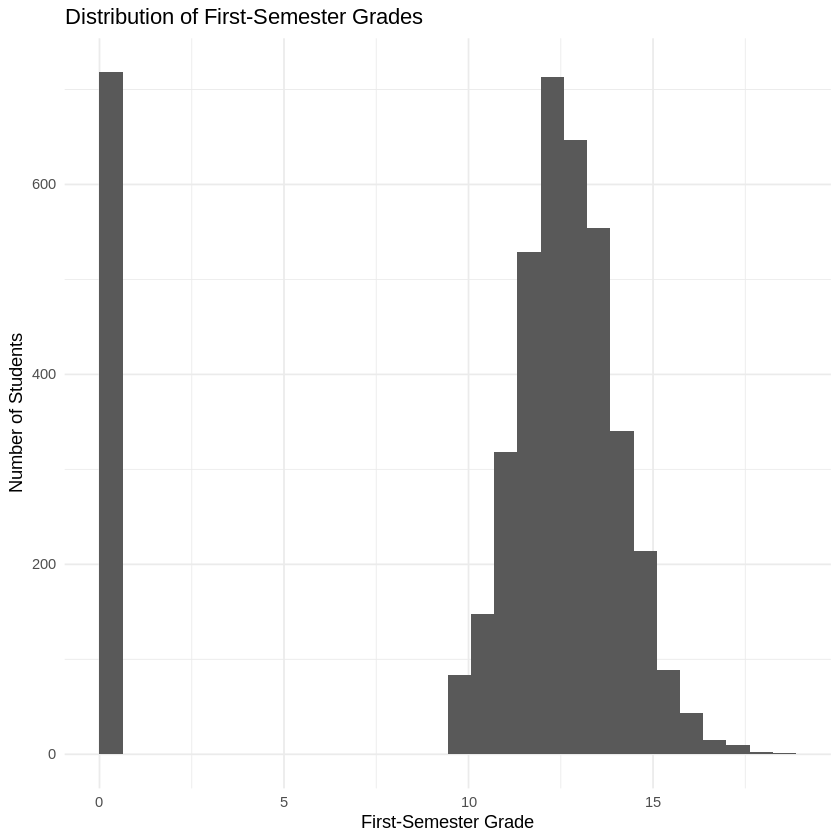

In [7]:
ggplot(
  students,
  aes(x = curricular_units_1st_sem_grade)
) +
  geom_histogram(
    bins = 30,
    boundary = 0
  ) +
  labs(
    title = "Distribution of First-Semester Grades",
    x = "First-Semester Grade",
    y = "Number of Students"
  ) +
  theme_minimal()

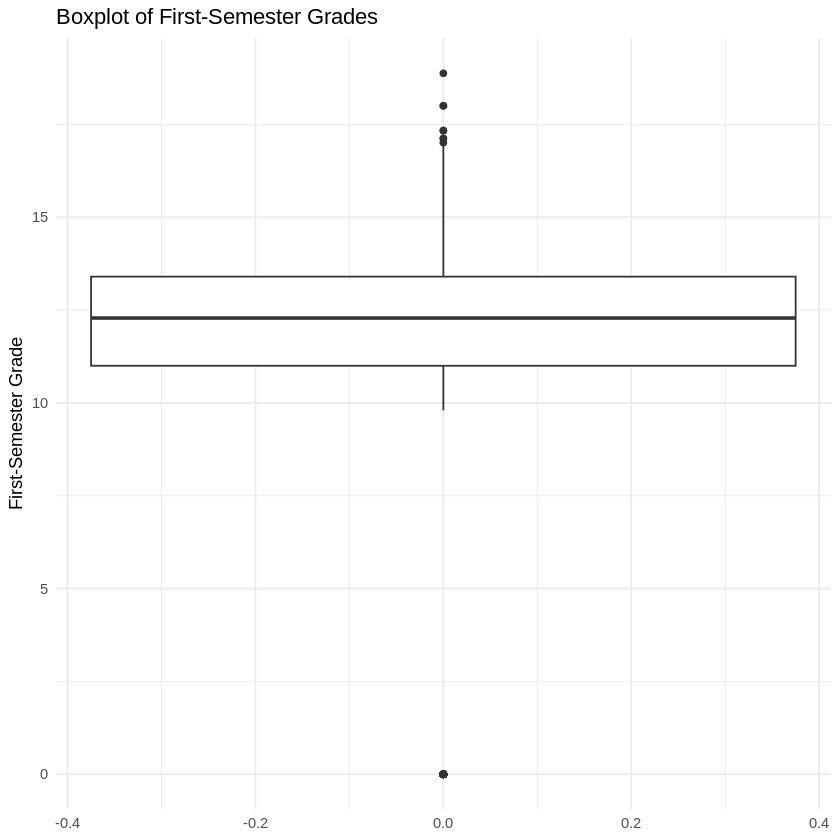

In [8]:
ggplot(
  students,
  aes(y = curricular_units_1st_sem_grade)
) +
  geom_boxplot() +
  labs(
    title = "Boxplot of First-Semester Grades",
    x = NULL,
    y = "First-Semester Grade"
  ) +
  theme_minimal()

## Visualization Results

The histogram showed that most nonzero first-semester grades were concentrated between approximately 10 and 15. The highest concentration appeared around grades 12 and 13.

The distribution also contained a large number of grades equal to zero. This created a separate bar at the beginning of the histogram rather than one continuous, approximately normal distribution.

The boxplot showed that the middle 50% of first-semester grades was approximately between 11 and 13.5, with a median near 12. Several grades above approximately 17 appeared as high outliers. The zero grades appeared as extreme low outliers.

## Data-Quality Interpretation

The large number of zero grades requires further investigation. A value of zero may represent a valid academic grade, but it may also represent students who did not complete an evaluation or did not receive a recorded grade.

The zero values should not be removed automatically. The project should compare them with variables such as the number of curricular units without evaluations before deciding how they should be interpreted.

## Practical Interpretation

For students with nonzero grades, first-semester performance was generally concentrated in the lower-to-middle teens on the grading scale. This suggests that most recorded grades were near the center of the observed nonzero distribution rather than at the highest end of the scale.

However, the large number of zero values strongly affects the overall distribution and will likely lower the calculated mean. For this reason, the mean and median should both be reported. The median may better represent a typical student grade when the zero values create a strongly unusual distribution.

A student success coordinator could use this pattern to investigate whether students with zero first-semester grades also had no completed evaluations or approved courses. This analysis alone does not explain why the zero grades occurred.

## Limitation

The graph does not show whether each zero represents a genuine earned grade, an incomplete academic record, or a student who did not participate in evaluations. The values should be investigated before they are interpreted as academic failure.

The analysis is descriptive and does not prove that first-semester grades caused students to drop out, remain enrolled, or graduate.

In [9]:
# Count students with a first-semester grade of zero
students |>
  summarise(
    zero_grade_count =
      sum(curricular_units_1st_sem_grade == 0, na.rm = TRUE),

    zero_grade_percentage =
      mean(curricular_units_1st_sem_grade == 0, na.rm = TRUE) * 100
  )

zero_grade_count,zero_grade_percentage
<int>,<dbl>
718,16.22966


In [10]:
# Review students with a first-semester grade of zero
students |>
  filter(curricular_units_1st_sem_grade == 0) |>
  summarise(
    students_with_zero_grade = n(),

    average_units_enrolled =
      mean(curricular_units_1st_sem_enrolled, na.rm = TRUE),

    average_units_approved =
      mean(curricular_units_1st_sem_approved, na.rm = TRUE),

    average_units_without_evaluations =
      mean(
        curricular_units_1st_sem_without_evaluations,
        na.rm = TRUE
      ),

    students_with_no_approved_units =
      sum(curricular_units_1st_sem_approved == 0, na.rm = TRUE)
  )

students_with_zero_grade,average_units_enrolled,average_units_approved,average_units_without_evaluations,students_with_no_approved_units
<int>,<dbl>,<dbl>,<dbl>,<int>
718,4.16156,0,0.2548747,718


## Data-Quality Results

The analysis found that 718 students had a first-semester grade equal to zero. This represents approximately 16.23% of the 4,424 students in the dataset.

Students with a zero first-semester grade enrolled in an average of approximately 4.16 curricular units. All 718 of these students had zero approved curricular units.

These students had an average of approximately 0.25 curricular units without evaluations. Therefore, the large number of zero grades does not appear to be explained only by students having no evaluations recorded.

The results suggest that a first-semester grade of zero is closely connected to approving no curricular units. However, the dataset documentation and related academic variables should still be reviewed before deciding exactly what every zero value represents.

The zero values should not be removed because they appear to contain meaningful academic information rather than being simple missing values.

## Updated Practical Interpretation

Most nonzero first-semester grades were concentrated between approximately 10 and 15, with the greatest concentration around grades 12 and 13.

However, 718 students, or approximately 16.23% of the dataset, had a first-semester grade of zero. All students in this group also approved zero first-semester curricular units.

This pattern suggests that the zero-grade group experienced substantially different first-semester academic results from students with nonzero grades. A student success coordinator may want to investigate whether students who approve no first-semester units face academic, financial, enrollment, or personal barriers that require additional support.

The large number of zero values will lower the overall mean and make the grade distribution strongly unusual. Therefore, both the mean and median should be reported. The median may provide a better description of the center of the typical nonzero grade distribution, while the mean reflects the effect of the zero-grade group.

## Updated Limitation

Although every student with a zero first-semester grade also approved zero curricular units, this analysis does not explain why those students approved no units.

The dataset may not include all relevant circumstances, such as course withdrawal, attendance, employment responsibilities, health concerns, financial hardship, or personal difficulties.

The analysis is descriptive and does not prove that a zero first-semester grade caused a student to drop out, remain enrolled, or graduate. The results should support further investigation rather than automatic decisions about individual students.

In [11]:
grade_summary <- students |>
  summarise(
    observations =
      sum(!is.na(curricular_units_1st_sem_grade)),

    missing_values =
      sum(is.na(curricular_units_1st_sem_grade)),

    mean =
      mean(curricular_units_1st_sem_grade, na.rm = TRUE),

    median =
      median(curricular_units_1st_sem_grade, na.rm = TRUE),

    standard_deviation =
      sd(curricular_units_1st_sem_grade, na.rm = TRUE),

    minimum =
      min(curricular_units_1st_sem_grade, na.rm = TRUE),

    first_quartile =
      quantile(
        curricular_units_1st_sem_grade,
        0.25,
        na.rm = TRUE
      ),

    third_quartile =
      quantile(
        curricular_units_1st_sem_grade,
        0.75,
        na.rm = TRUE
      ),

    maximum =
      max(curricular_units_1st_sem_grade, na.rm = TRUE),

    range =
      max(curricular_units_1st_sem_grade, na.rm = TRUE) -
      min(curricular_units_1st_sem_grade, na.rm = TRUE)
  )

grade_summary

observations,missing_values,mean,median,standard_deviation,minimum,first_quartile,third_quartile,maximum,range
<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4424,0,10.64082,12.28571,4.843663,0,11,13.4,18.875,18.875


## Descriptive Statistics Results

The first-semester grade variable contained 4,424 valid observations and no missing values.

The mean first-semester grade was approximately 10.64, while the median was approximately 12.29. The median was higher than the mean because the large number of zero grades pulled the mean downward.

The standard deviation was approximately 4.84, showing that first-semester grades varied considerably across students.

The minimum grade was 0, and the maximum grade was 18.88, producing a range of 18.88 points.

The first quartile was 11, meaning approximately 25% of students had grades at or below 11. The third quartile was 13.4, meaning approximately 75% of students had grades at or below 13.4. The middle 50% of grades therefore fell between 11 and 13.4.

## Visualization Results

The histogram showed that most nonzero first-semester grades were concentrated between approximately 10 and 15. The highest concentration appeared around grades 12 and 13.

The distribution also contained a large number of grades equal to zero. These values created a separate bar at the beginning of the histogram rather than one continuous, approximately normal distribution.

The boxplot showed that the middle 50% of first-semester grades was between 11 and 13.4, with a median of approximately 12.29. Several grades near the upper end of the scale appeared as high outliers. The zero grades appeared as extreme low outliers.

## Data-Quality Results

The analysis found that 718 students had a first-semester grade equal to zero. This represents approximately 16.23% of the 4,424 students in the dataset.

Students with a zero first-semester grade enrolled in an average of approximately 4.16 curricular units. All 718 of these students had zero approved curricular units.

These students had an average of approximately 0.25 curricular units without evaluations. Therefore, the zero grades do not appear to be explained only by students having no evaluations recorded.

The zero values were retained because they appear to contain meaningful academic information rather than being simple missing values.

## Practical Interpretation

The typical student grade was better represented by the median of 12.29 than by the mean of 10.64 because the large number of zero grades lowered the mean.

Most students in the middle half of the distribution had first-semester grades between 11 and 13.4. However, approximately 16.23% of students had a grade of zero, and every student in this group approved zero first-semester curricular units.

This pattern may help a student success coordinator identify an area requiring further investigation. Students who approve no first-semester units may be experiencing academic, financial, enrollment, or personal barriers.

The analysis does not identify the cause of these results, so staff should use the findings to guide supportive investigation rather than assume why the students received zero grades.

## Limitation

Although every student with a zero first-semester grade also approved zero curricular units, this analysis does not explain why those students approved no units.

The dataset may not include all relevant circumstances, such as course withdrawals, attendance, employment responsibilities, health concerns, financial hardship, or personal difficulties.

The analysis is descriptive and does not prove that first-semester grades caused students to drop out, remain enrolled, or graduate. The results should not be used to make automatic decisions about individual students.

# Part 6: Required Skill 2 — Compare Two Groups

## Comparison Question

Do students whose tuition fees are up to date have a different dropout rate than students whose tuition fees are not up to date?

## Outcome Variable

The outcome variable is `dropout_status`.

This is a binary variable created from `target`:

- `Dropout`
- `Not Dropout`

Students classified as `Enrolled` or `Graduate` are included in the `Not Dropout` category for this comparison.

## Grouping Variable

The grouping variable is `tuition_fees_up_to_date`.

This variable contains two groups:

- Tuition fees not up to date
- Tuition fees up to date

## Statistical Method

A two-proportion test will be used to compare the proportion of students who dropped out in the two tuition-status groups.

This method is appropriate because:

- The grouping variable contains two groups.
- The outcome is binary.
- The question compares two proportions.
- The dataset contains enough observations for both groups.

The analysis will report:

- Sample size for each tuition-status group
- Number of students who dropped out in each group
- Dropout percentage for each group
- Estimated difference in dropout proportions
- 95% confidence interval
- P-value
- Practical interpretation
- Limitation

## Validation

Before running the comparison, the skill will check that:

- `tuition_fees_up_to_date` exists.
- `target` exists.
- The tuition-status variable contains exactly two valid groups.
- The outcome is converted into a binary dropout variable.
- Both groups contain enough observations.
- Missing values are handled consistently.
- The expected counts are large enough for a two-proportion test.
- The selected method matches the categorical variables.

## Practical Purpose

This comparison may help a student success coordinator understand whether dropout patterns differ between students whose tuition fees are current and students whose tuition fees are not current.

The result may support further investigation into whether financial-support outreach or payment assistance should be reviewed.

## Limitation

A difference in dropout percentages does not prove that tuition-payment status caused students to drop out.

Tuition status may be related to other factors, such as employment, family responsibilities, financial hardship, academic performance, or access to financial aid.

The result should be used to identify a group-level pattern and guide supportive investigation. It should not be used to penalize or automatically classify individual students.

In [12]:
#1. Confirm the variables exist

"tuition_fees_up_to_date" %in% names(students)
"target" %in% names(students)

table(students$tuition_fees_up_to_date)
table(students$target)

[1] TRUE

[1] TRUE


   0    1 
 528 3896 


 Dropout Enrolled Graduate 
    1421      794     2209 

In [13]:
#2. Create readable group labels and a binary dropout outcome

compare_data <- students |>
  mutate(
    tuition_status = factor(
      tuition_fees_up_to_date,
      levels = c(0, 1),
      labels = c(
        "Tuition Not Up to Date",
        "Tuition Up to Date"
      )
    ),

    dropout_status = factor(
      if_else(
        target == "Dropout",
        "Dropout",
        "Not Dropout"
      ),
      levels = c("Not Dropout", "Dropout")
    )
  )

In [14]:
#3. Check missing values and the two groups

compare_data |>
  summarise(
    missing_tuition_status =
      sum(is.na(tuition_status)),

    missing_dropout_status =
      sum(is.na(dropout_status))
  )

table(compare_data$tuition_status)
table(compare_data$dropout_status)

missing_tuition_status,missing_dropout_status
<int>,<int>
0,0



Tuition Not Up to Date     Tuition Up to Date 
                   528                   3896 


Not Dropout     Dropout 
       3003        1421 

In [15]:
#4. Calculate sample sizes and dropout percentages

group_results <- compare_data |>
  group_by(tuition_status) |>
  summarise(
    sample_size = n(),

    dropout_count =
      sum(dropout_status == "Dropout"),

    not_dropout_count =
      sum(dropout_status == "Not Dropout"),

    dropout_percentage =
      mean(dropout_status == "Dropout") * 100,

    .groups = "drop"
  )

group_results

tuition_status,sample_size,dropout_count,not_dropout_count,dropout_percentage
<fct>,<int>,<int>,<int>,<dbl>
Tuition Not Up to Date,528,457,71,86.55303
Tuition Up to Date,3896,964,2932,24.74333


In [16]:
#5. Create the contingency table

tuition_dropout_table <- table(
  compare_data$tuition_status,
  compare_data$dropout_status
)

tuition_dropout_table

                        
                         Not Dropout Dropout
  Tuition Not Up to Date          71     457
  Tuition Up to Date            2932     964

In [17]:
#6. Check expected counts

chi_result <- chisq.test(tuition_dropout_table)

chi_result$expected

,Not Dropout,Dropout
Tuition Not Up to Date,358.4051,169.5949
Tuition Up to Date,2644.5949,1251.4051


In [18]:
#7. Run the two-proportion test

dropout_counts <- group_results$dropout_count
group_sizes <- group_results$sample_size

proportion_test <- prop.test(
  x = dropout_counts,
  n = group_sizes,
  alternative = "two.sided",
  conf.level = 0.95,
  correct = FALSE
)

proportion_test


	2-sample test for equality of proportions without continuity correction

data:  dropout_counts out of group_sizes
X-squared = 814.76, df = 1, p-value < 2.2e-16
alternative hypothesis: two.sided
95 percent confidence interval:
 0.5859975 0.6501966
sample estimates:
   prop 1    prop 2 
0.8655303 0.2474333 


In [19]:
#8. Calculate the estimated difference

dropout_proportions <-
  group_results$dropout_count /
  group_results$sample_size

estimated_difference <-
  dropout_proportions[1] -
  dropout_proportions[2]

estimated_difference

estimated_difference_percentage_points <-
  estimated_difference * 100

estimated_difference_percentage_points

[1] 0.618097

[1] 61.8097

In [20]:
#9.Display the confidence interval

proportion_test$conf.int
proportion_test$conf.int * 100

[1] 0.5859975 0.6501966
attr(,"conf.level")
[1] 0.95

[1] 58.59975 65.01966
attr(,"conf.level")
[1] 0.95

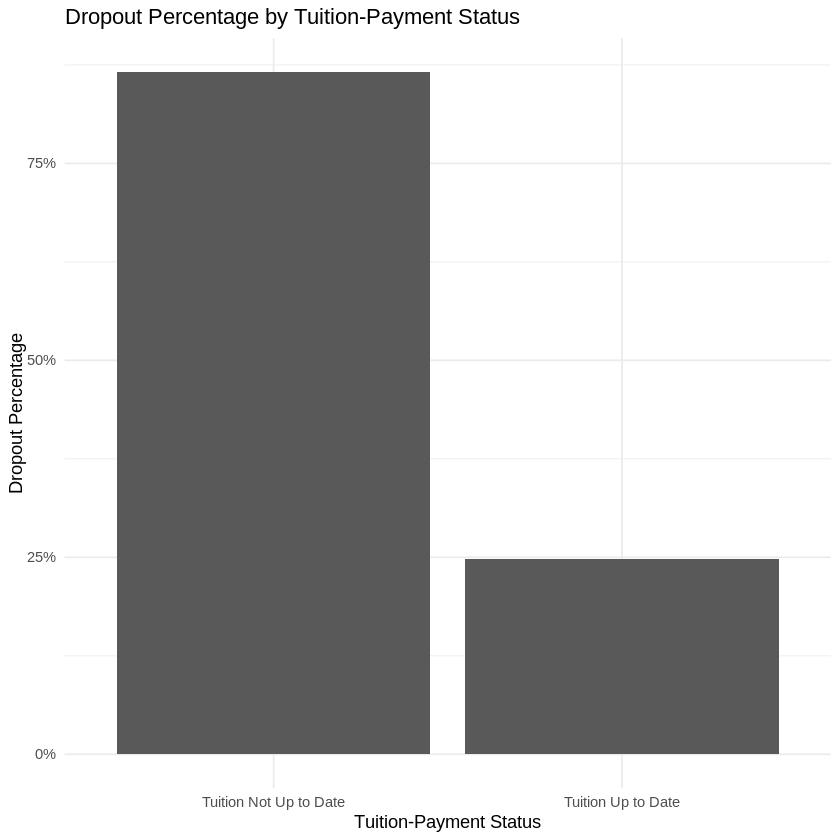

In [21]:
#10. Create a comparison chart

ggplot(
  group_results,
  aes(
    x = tuition_status,
    y = dropout_percentage
  )
) +
  geom_col() +
  labs(
    title = "Dropout Percentage by Tuition-Payment Status",
    x = "Tuition-Payment Status",
    y = "Dropout Percentage"
  ) +
  scale_y_continuous(
    labels = scales::label_percent(scale = 1)
  ) +
  theme_minimal()

## Comparison Results

The tuition-status groups were very different in size.

Among students whose tuition fees were not up to date, 457 out of 528 students dropped out. This represents a dropout rate of approximately 86.55%.

Among students whose tuition fees were up to date, 964 out of 3,896 students dropped out. This represents a dropout rate of approximately 24.74%.

The estimated difference in dropout rates was approximately 61.81 percentage points. In other words, the observed dropout rate was about 61.81 percentage points higher among students whose tuition fees were not up to date.

The 95% confidence interval for this difference ranged from approximately 58.60 to 65.02 percentage points. This interval suggests that the true difference in dropout rates within the population represented by this dataset is likely to be large.

The two-proportion test produced a p-value smaller than 2.2 × 10⁻¹⁶. This provides very strong statistical evidence that dropout rates differ between the two tuition-status groups.

## Practical Interpretation

Students whose tuition fees were not up to date had a substantially higher observed dropout rate than students whose tuition fees were up to date.

The difference was not only statistically significant but also practically large. A difference of approximately 61.81 percentage points is large enough to be meaningful for student-retention planning.

This result may help a college student success coordinator recognize that tuition-payment difficulties are closely associated with dropout in this dataset. The institution may want to investigate whether students with unpaid tuition are also experiencing financial hardship, administrative barriers, limited access to financial aid, or other challenges.

The result should support voluntary financial guidance and outreach rather than punitive action.

## Uncertainty

The confidence interval indicates that the estimated difference is not exact. Based on this sample, the difference could reasonably be approximately 58.60 to 65.02 percentage points.

Even at the lower end of the confidence interval, the observed difference remains substantial.

## Limitation

This analysis shows a strong association between tuition-payment status and dropout, but it does not prove that unpaid tuition directly caused students to drop out.

Other factors may affect both tuition status and student outcomes, including income, employment, family responsibilities, financial aid access, academic performance, and personal circumstances.

Students classified as Enrolled or Graduate were combined into the Not Dropout category for this analysis. This simplifies the three-category outcome and does not distinguish between students who completed their degree and students who were still enrolled.

The result should not be used to judge, penalize, or automatically classify individual students. It should be used to identify a group-level pattern that may require further investigation and supportive outreach.

# Part 7: Required Skill 3 — Use a Statistical Model

## Model Question

Which academic and financial factors are associated with whether a student drops out rather than graduates?

## Outcome Variable

The outcome variable is `dropout_status`.

It is created from the original `target` variable:

- `0 = Graduate`
- `1 = Dropout`

Students classified as `Enrolled` are excluded from this model because they have not yet reached a final graduation or dropout outcome.

## Predictor Variables

The model will use the following predictors:

- `curricular_units_1st_sem_grade`
- `curricular_units_1st_sem_approved`
- `tuition_fees_up_to_date`
- `debtor`
- `scholarship_holder`
- `admission_grade`
- `age_at_enrollment`

These variables were selected because they represent early academic performance, financial status, prior academic preparation, and student characteristics that may be associated with dropout.

## Reason for Selecting Logistic Regression

Binary logistic regression is appropriate because the outcome has two categories: Graduate and Dropout.

The model estimates the probability that a student belongs to the Dropout group based on the selected predictors.

Logistic regression also produces odds ratios. An odds ratio greater than 1 indicates higher estimated odds of dropout, while an odds ratio below 1 indicates lower estimated odds of dropout, holding the other predictors constant.

## Training and Testing Data

The data will be divided into:

- 80% training data
- 20% testing data

The training data will be used to build the model.

The testing data will be used to evaluate how well the model performs on observations that were not used to fit it.

## Model Evaluation

The model will be evaluated using:

- Accuracy
- Sensitivity
- Specificity
- Precision
- F1 score
- Area under the ROC curve

Accuracy alone will not be used because the Graduate and Dropout groups are not exactly equal in size.

Sensitivity will show how well the model identifies students in the Dropout group.

Specificity will show how well the model identifies students in the Graduate group.

The area under the ROC curve will measure how well the model separates Dropout and Graduate observations across possible classification thresholds.

## Validation

Before fitting the model, the analysis will check that:

- The outcome contains exactly two categories.
- All predictors exist.
- Numeric predictors contain variation.
- Binary predictors contain both categories.
- Missing values are handled consistently.
- The number of predictors is reasonable for the number of observations.
- Predictors do not directly reveal the final outcome.
- The model converges without warnings.
- The same predictor structure is used in the training and testing data.

## Practical Interpretation

The model will help identify which academic and financial factors have the strongest adjusted associations with dropout.

The results may help a student success coordinator understand broad patterns connected to student retention and decide which areas require additional investigation.

The model should support voluntary outreach and support planning. It should not be used to rank students or automatically make decisions about individual students.

## Limitation

Logistic regression identifies associations, not causes.

A predictor may be statistically associated with dropout without directly causing the student to leave college.

The model may also produce false positives and false negatives. Some students predicted as higher risk may graduate, while some students predicted as lower risk may drop out.

Because the dataset comes from one institution, the model may not perform equally well at other colleges or universities.

The model must not be used to deny financial aid, enrollment, advising, or other educational opportunities.

In [22]:
#1. Create the model data

model_data <- students |>
  filter(target %in% c("Dropout", "Graduate")) |>
  mutate(
    dropout_status = if_else(target == "Dropout", 1, 0),
    tuition_fees_up_to_date = factor(tuition_fees_up_to_date),
    debtor = factor(debtor),
    scholarship_holder = factor(scholarship_holder)
  ) |>
  select(
    dropout_status,
    curricular_units_1st_sem_grade,
    curricular_units_1st_sem_approved,
    tuition_fees_up_to_date,
    debtor,
    scholarship_holder,
    admission_grade,
    age_at_enrollment
  )

dim(model_data)
table(model_data$dropout_status)
colSums(is.na(model_data))

[1] 3630    8


   0    1 
2209 1421 

dropout_status    curricular_units_1st_sem_grade 
                                0                                 0 
curricular_units_1st_sem_approved           tuition_fees_up_to_date 
                                0                                 0 
                           debtor                scholarship_holder 
                                0                                 0 
                  admission_grade                 age_at_enrollment 
                                0                                 0

In [23]:
#2.Split into training and testing data

set.seed(123)

training_rows <- sample(
  seq_len(nrow(model_data)),
  size = floor(0.80 * nrow(model_data))
)

training_data <- model_data[training_rows, ]
testing_data <- model_data[-training_rows, ]

dim(training_data)
dim(testing_data)

[1] 2904    8

[1] 726   8

In [24]:
#3.Fit the logistic regression

dropout_model <- glm(
  dropout_status ~
    curricular_units_1st_sem_grade +
    curricular_units_1st_sem_approved +
    tuition_fees_up_to_date +
    debtor +
    scholarship_holder +
    admission_grade +
    age_at_enrollment,
  data = training_data,
  family = binomial
)

summary(dropout_model)
dropout_model$converged


Call:
glm(formula = dropout_status ~ curricular_units_1st_sem_grade + 
    curricular_units_1st_sem_approved + tuition_fees_up_to_date + 
    debtor + scholarship_holder + admission_grade + age_at_enrollment, 
    family = binomial, data = training_data)

Coefficients:
                                   Estimate Std. Error z value Pr(>|z|)    
(Intercept)                        5.950099   0.597040   9.966  < 2e-16 ***
curricular_units_1st_sem_grade    -0.066509   0.018536  -3.588 0.000333 ***
curricular_units_1st_sem_approved -0.410190   0.032987 -12.435  < 2e-16 ***
tuition_fees_up_to_date1          -2.970707   0.266024 -11.167  < 2e-16 ***
debtor1                            1.024425   0.200231   5.116 3.12e-07 ***
scholarship_holder1               -1.289320   0.143259  -9.000  < 2e-16 ***
admission_grade                   -0.016888   0.003733  -4.524 6.07e-06 ***
age_at_enrollment                  0.051412   0.006872   7.482 7.33e-14 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘

[1] TRUE

In [25]:
#4.Create odds ratios

odds_ratios <- exp(coef(dropout_model))

odds_ratio_table <- data.frame(
  predictor = names(odds_ratios),
  odds_ratio = odds_ratios
)

odds_ratio_table

,predictor,odds_ratio
,<chr>,<dbl>
(Intercept),(Intercept),383.79128313
curricular_units_1st_sem_grade,curricular_units_1st_sem_grade,0.93565437
curricular_units_1st_sem_approved,curricular_units_1st_sem_approved,0.66352386
tuition_fees_up_to_date1,tuition_fees_up_to_date1,0.05126703
debtor1,debtor1,2.78549285
scholarship_holder1,scholarship_holder1,0.27545816
admission_grade,admission_grade,0.98325384
age_at_enrollment,age_at_enrollment,1.05275670


In [26]:
#5.Make predictions

testing_data$predicted_probability <- predict(
  dropout_model,
  newdata = testing_data,
  type = "response"
)

testing_data$predicted_class <- ifelse(
  testing_data$predicted_probability >= 0.50,
  1,
  0
)

In [27]:
#6.Confusion matrix and metrics

confusion_table <- table(
  Predicted = testing_data$predicted_class,
  Actual = testing_data$dropout_status
)

confusion_table

         Actual
Predicted   0   1
        0 421  73
        1  30 202

In [28]:
true_negative <- confusion_table["0", "0"]
false_negative <- confusion_table["0", "1"]
false_positive <- confusion_table["1", "0"]
true_positive <- confusion_table["1", "1"]

accuracy <- (
  true_positive + true_negative
) / sum(confusion_table)

sensitivity <- true_positive / (
  true_positive + false_negative
)

specificity <- true_negative / (
  true_negative + false_positive
)

model_metrics <- data.frame(
  accuracy = accuracy,
  sensitivity = sensitivity,
  specificity = specificity
)

model_metrics

accuracy,sensitivity,specificity
<dbl>,<dbl>,<dbl>
0.8581267,0.7345455,0.9334812


In [29]:
summary(dropout_model)


Call:
glm(formula = dropout_status ~ curricular_units_1st_sem_grade + 
    curricular_units_1st_sem_approved + tuition_fees_up_to_date + 
    debtor + scholarship_holder + admission_grade + age_at_enrollment, 
    family = binomial, data = training_data)

Coefficients:
                                   Estimate Std. Error z value Pr(>|z|)    
(Intercept)                        5.950099   0.597040   9.966  < 2e-16 ***
curricular_units_1st_sem_grade    -0.066509   0.018536  -3.588 0.000333 ***
curricular_units_1st_sem_approved -0.410190   0.032987 -12.435  < 2e-16 ***
tuition_fees_up_to_date1          -2.970707   0.266024 -11.167  < 2e-16 ***
debtor1                            1.024425   0.200231   5.116 3.12e-07 ***
scholarship_holder1               -1.289320   0.143259  -9.000  < 2e-16 ***
admission_grade                   -0.016888   0.003733  -4.524 6.07e-06 ***
age_at_enrollment                  0.051412   0.006872   7.482 7.33e-14 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘

In [30]:
odds_ratio_table

,predictor,odds_ratio
,<chr>,<dbl>
(Intercept),(Intercept),383.79128313
curricular_units_1st_sem_grade,curricular_units_1st_sem_grade,0.93565437
curricular_units_1st_sem_approved,curricular_units_1st_sem_approved,0.66352386
tuition_fees_up_to_date1,tuition_fees_up_to_date1,0.05126703
debtor1,debtor1,2.78549285
scholarship_holder1,scholarship_holder1,0.27545816
admission_grade,admission_grade,0.98325384
age_at_enrollment,age_at_enrollment,1.05275670


In [31]:
confusion_table

         Actual
Predicted   0   1
        0 421  73
        1  30 202

In [32]:
model_metrics

accuracy,sensitivity,specificity
<dbl>,<dbl>,<dbl>
0.8581267,0.7345455,0.9334812


## Model Results

The logistic regression model examined which academic and financial factors were associated with dropping out rather than graduating.

The model was trained using 2,904 students. Students who were still classified as Enrolled were excluded because their final outcome was not yet known.

The model included the following predictors:

- First-semester grade
- Number of first-semester curricular units approved
- Tuition-fee status
- Debtor status
- Scholarship status
- Admission grade
- Age at enrollment

All seven predictors showed statistically significant adjusted associations with dropout in the training data.

## Important Predictors

### First-Semester Grade

The odds ratio for first-semester grade was approximately 0.94.

Holding the other predictors constant, each one-point increase in first-semester grade was associated with approximately a 6.4% decrease in the estimated odds of dropout.

### First-Semester Units Approved

The odds ratio for the number of first-semester units approved was approximately 0.66.

Holding the other predictors constant, each additional approved curricular unit was associated with approximately a 33.6% decrease in the estimated odds of dropout.

This was one of the strongest academic factors in the model.

### Tuition Fees Up to Date

The odds ratio for having tuition fees up to date was approximately 0.05.

Holding the other predictors constant, students whose tuition fees were up to date had substantially lower estimated odds of dropout than students whose tuition fees were not up to date.

This result is consistent with the earlier two-group comparison, which also found a large difference in dropout rates by tuition-payment status.

### Debtor Status

The odds ratio for debtor status was approximately 2.79.

Holding the other variables constant, students identified as debtors had about 2.79 times the estimated odds of dropout compared with students who were not identified as debtors.

### Scholarship Status

The odds ratio for scholarship-holder status was approximately 0.28.

Holding the other predictors constant, scholarship holders had lower estimated odds of dropout than students who were not scholarship holders.

### Admission Grade

The odds ratio for admission grade was approximately 0.98.

Each one-point increase in admission grade was associated with a small decrease of approximately 1.7% in the estimated odds of dropout, holding the other predictors constant.

Although the association was statistically significant, its size was smaller than the associations for tuition status, approved units, debtor status, and scholarship status.

### Age at Enrollment

The odds ratio for age at enrollment was approximately 1.05.

Holding the other predictors constant, each additional year of age at enrollment was associated with approximately a 5.3% increase in the estimated odds of dropout.

This result should not be interpreted as age causing dropout. Age may be connected to employment, caregiving responsibilities, time away from school, or other circumstances that are not fully represented in the dataset.

## Model Evaluation

The testing dataset contained 726 students.

The confusion matrix results were:

- 421 graduates were correctly classified as Graduate.
- 202 dropout students were correctly classified as Dropout.
- 30 graduates were incorrectly classified as Dropout.
- 73 dropout students were incorrectly classified as Graduate.

The model achieved an accuracy of approximately 85.81%.

This means that the model correctly classified approximately 86 out of every 100 students in the testing dataset.

The model sensitivity was approximately 73.45%.

This means that the model correctly identified approximately 73% of the students who actually dropped out. However, it missed approximately 27% of the dropout students.

The model specificity was approximately 93.35%.

This means that the model correctly identified approximately 93% of the students who actually graduated.

The model was therefore better at identifying graduates than at identifying students who dropped out.

## Practical Interpretation

The model suggests that both academic progress and financial circumstances are associated with student dropout.

The factors with especially important adjusted associations included:

- Tuition fees being up to date
- Number of first-semester curricular units approved
- Debtor status
- Scholarship status
- First-semester grade

For a college student success coordinator, these findings suggest that first-semester course completion and financial circumstances may be useful areas for further review when planning retention services.

The model may support broad institutional decisions, such as reviewing academic-support programs, financial counseling, scholarship access, and early-semester outreach.

However, the model should not be used to rank individual students or automatically determine who receives services.

## Limitation

The model identifies adjusted statistical associations, not causes.

For example, the result does not prove that being a debtor, being older, or having tuition fees that are not current directly causes a student to drop out.

The model may also produce incorrect classifications. In the testing data, 73 students who actually dropped out were classified as graduates, while 30 students who actually graduated were classified as dropouts.

Important personal and institutional factors may not be included in the dataset, such as employment schedules, caregiving responsibilities, transportation, health, housing, course difficulty, or access to support services.

Because the dataset comes from one higher-education institution, the model may not perform equally well at other colleges or universities.

The model should only support voluntary outreach, further investigation, and professional judgment. It should never be used to deny financial aid, enrollment, advising, or educational opportunities.

# Part 8: Create Three Additional Skills

The project will include three additional statistical skills connected to the same higher-education student retention problem.

The three additional skills are:

1. Academic Progress Analysis
2. Program Support Prioritization
3. Data Quality Audit

Each skill uses R, includes validation rules, produces a useful result, provides a practical interpretation, and includes a limitation.

---

# Additional Skill 1: Academic Progress Analysis

## Skill Question

How does first-semester academic progress differ among students who dropped out, remained enrolled, or graduated?

## Purpose

This skill examines first-semester academic progress across the three student outcome groups:

- Dropout
- Enrolled
- Graduate

The purpose is to help a college student success coordinator understand whether students with different final outcomes had different first-semester grades, course completion levels, or approval rates.

## Variables Used

The skill will use:

- `curricular_units_1st_sem_enrolled`
- `curricular_units_1st_sem_approved`
- `curricular_units_1st_sem_grade`
- `curricular_units_1st_sem_evaluations`
- `curricular_units_1st_sem_without_evaluations`
- `target`

The skill will also calculate a first-semester approval rate:

`curricular_units_1st_sem_approved / curricular_units_1st_sem_enrolled`

The approval rate will be stored as a proportion between 0 and 1. It will be displayed as a percentage when appropriate.

## Method

The skill will use:

- Sample sizes for each outcome group
- Mean and median first-semester grades
- Mean and median courses approved
- Mean and median approval rates
- Group summary tables
- Boxplots or bar charts
- One-way ANOVA, Welch ANOVA, or Kruskal-Wallis testing when appropriate
- Effect-size measures when appropriate

The selected statistical test will depend on the distribution, outliers, and variance patterns in the data.

## Validation

Before running the analysis, the skill will confirm that:

- All requested variables exist.
- Academic variables are numeric.
- Course counts are not negative.
- Approved units do not exceed enrolled units.
- Division by zero is prevented.
- Approval rates remain between 0 and 1.
- Each outcome group contains enough usable observations.
- Missing values are handled consistently.
- The selected statistical method matches the variable type and assumptions.

If enrolled units equal zero, an approval rate will not be calculated for that record.

## Output

The skill will return:

- Sample size for each outcome group
- Mean and median first-semester grades
- Average courses enrolled and approved
- First-semester approval rates
- A summary table
- A visualization
- Statistical test results when requested
- Effect size when appropriate
- Practical interpretation
- Limitation

## Practical Interpretation

The results may help student success staff understand whether first-semester academic patterns differ among students who later dropped out, remained enrolled, or graduated.

For example, if students who later dropped out approved fewer courses on average, the institution could investigate whether tutoring, advising, course planning, or other early support services require further review.

The analysis should focus on broad student-group patterns rather than automatically labeling individual students.

## Limitation

This is a retrospective analysis because first-semester performance is being compared with outcomes recorded later.

The results do not prove that first-semester grades or course approval rates caused students to drop out or graduate.

The results also do not prove that the same measures will accurately predict the outcome of a student who is currently enrolled.

Other academic, financial, personal, and institutional circumstances may influence student outcomes.

---

# Additional Skill 2: Program Support Prioritization

## Skill Question

Which academic programs have the highest observed dropout percentages and may require further review?

## Purpose

This skill summarizes and ranks academic programs according to student outcome patterns.

It helps college administrators decide which programs may require further investigation, advising review, tutoring resources, or retention-support planning.

The skill prioritizes programs for review. It does not rank individual students.

## Variables Used

The skill will use:

- `course`
- `target`

The `target` variable contains:

- Dropout
- Enrolled
- Graduate

The numeric course codes will be converted into readable program labels before results are presented.

## Method

For each academic program, the skill will calculate:

- Total number of students
- Number of students who dropped out
- Number of students who remained enrolled
- Number of students who graduated
- Dropout percentage
- Enrolled percentage
- Graduation percentage
- Ranking by dropout percentage
- Confidence interval for the dropout proportion when appropriate

A horizontal bar chart will display dropout percentages across academic programs.

## Validation

Before creating the ranking, the skill will confirm that:

- `course` exists.
- `target` exists.
- Course codes are correctly matched to documented program labels.
- The outcome contains the expected categories.
- Missing values are handled consistently.
- Each displayed program has a sufficient sample size.
- Programs with very small sample sizes are flagged.
- Percentages are calculated within each program.
- Ties are handled consistently.
- The ranking is not described as a direct measure of program quality.

Programs with very small groups should not be ranked without a warning because their percentages may be unstable.

## Output

The skill will return:

- Program sample sizes
- Dropout counts and percentages
- Enrolled counts and percentages
- Graduation counts and percentages
- A ranked program table
- Confidence intervals when appropriate
- A horizontal bar chart
- Programs identified for further review
- Practical interpretation
- Limitation

## Decision Supported

This skill helps administrators prioritize which academic programs should be reviewed first.

A program with a high dropout percentage and a sufficiently large sample may deserve additional investigation into:

- Advising availability
- Tutoring access
- Course scheduling
- Curriculum structure
- Financial barriers
- Student workload
- Characteristics of the students served

The ranking should guide further investigation rather than automatically determine where resources must be removed or added.

## Practical Interpretation

The interpretation will explain which programs had the highest and lowest observed dropout percentages, the approximate size of the differences, and whether the ranking appears stable based on program sample sizes.

Programs with higher dropout percentages may require closer review. However, the result does not prove that the program itself caused students to drop out.

## Limitation

Academic programs may enroll students with different levels of academic preparation, financial circumstances, schedules, employment responsibilities, and personal obligations.

A higher dropout percentage does not prove that a program is poor quality or that its faculty caused students to leave.

The ranking should not be used to punish programs or make automatic funding decisions without additional investigation.

---

# Additional Skill 3: Data Quality Audit

## Skill Question

Are missing values, duplicate records, invalid codes, or unusual academic values affecting the reliability of the student analysis?

## Purpose

This skill checks whether data-quality problems could affect the statistical results.

It helps the analyst and student success coordinator determine whether the dataset is ready for analysis or whether additional cleaning and investigation are needed.

## Variables Used

The skill may examine all variables in the dataset, with special attention to:

- `target`
- `course`
- `curricular_units_1st_sem_enrolled`
- `curricular_units_1st_sem_approved`
- `curricular_units_1st_sem_grade`
- `tuition_fees_up_to_date`
- `debtor`
- `scholarship_holder`

## Method

The audit will perform:

- Missing-value counts
- Missing-value percentages
- Duplicate-row detection
- Data-type checks
- Unique-value counts
- Invalid-category checks
- Negative-value checks
- Logical consistency checks
- Range checks
- Unusual-value detection
- A summary of affected variables

Examples of logical checks include:

- Approved units should not exceed enrolled units.
- Course counts should not be negative.
- Binary variables should contain only their documented codes.
- `target` should contain only Dropout, Enrolled, and Graduate.
- Approval rates should fall between 0 and 1.
- Zero values should not automatically be treated as missing.

## Validation

Before running the audit, the skill will confirm that:

- The dataset exists and can be imported.
- The dataset contains observations and variables.
- Required variables are present.
- Documented codes are reviewed before values are labeled invalid.
- The official grading scale is checked before grade values are rejected.
- Suspected problems are flagged rather than silently deleted.
- The original dataset remains unchanged.
- Missing values are distinguished from valid zero values.

## Output

The skill will return:

- Number of observations
- Number of variables
- Total missing-value count
- Missing-value count by variable
- Missing-value percentage by variable
- Duplicate-row count
- Invalid-category count
- Logical inconsistency count
- Variables affected by quality issues
- Data-quality summary table
- Bar chart of detected issues
- Overall readiness result

The overall readiness result may be:

- Ready for analysis
- Ready with warnings
- Cleaning required

## Quantitative Result

The skill may calculate a simple data-quality score:

`Data-quality score = 100 − percentage of records affected by documented data-quality problems`

The score must be reported together with the number and type of problems found. It should not replace the detailed audit results.

## Current Known Data-Quality Findings

Earlier R checks confirmed that the dataset contains:

- 4,424 observations
- 37 variables
- 0 missing values
- 0 completely duplicated rows

The first-semester grade analysis also found:

- 718 students with a first-semester grade of zero
- Approximately 16.23% of students had a zero grade
- All 718 students with a zero grade approved zero first-semester units

These zero values were retained because they appear to contain meaningful academic information rather than being missing values.

## Practical Interpretation

The Data Quality Audit helps determine whether later statistical findings can be interpreted with reasonable confidence.

A dataset may contain no missing values or duplicates but still contain unusual values or logical inconsistencies that require investigation.

The audit helps identify those issues before statistical tests or models are interpreted.

## Limitation

Passing automated quality checks does not prove that every value is correct.

Some incorrect values may still fall within an acceptable range, while some unusual values may be legitimate.

The audit should identify possible issues for review. It should not automatically delete or change observations without documentation.

---

# Part 8 Requirement Check

The three additional skills meet the project requirements:

- Academic Progress Analysis produces summary statistics, statistical comparisons, and visualizations.
- Program Support Prioritization produces a ranking and supports a decision about which programs should be reviewed first.
- Data Quality Audit produces counts, a readiness result, a possible data-quality score, and a visualization.
- All three skills use R.
- All three contain validation rules.
- All three support the same higher-education student retention problem.
- All three provide practical interpretations.
- All three include limitations.
- All three are different from the required Explore, Compare Two Groups, and Statistical Model skills.

In [33]:
#1.Create the approval-rate variable

academic_progress <- students |>
  mutate(
    approval_rate = if_else(
      curricular_units_1st_sem_enrolled > 0,
      curricular_units_1st_sem_approved /
        curricular_units_1st_sem_enrolled,
      NA_real_
    )
  )

In [34]:
#2.alidate the data

academic_progress |>
  summarise(
    negative_enrolled =
      sum(curricular_units_1st_sem_enrolled < 0),

    negative_approved =
      sum(curricular_units_1st_sem_approved < 0),

    approved_greater_than_enrolled =
      sum(
        curricular_units_1st_sem_approved >
          curricular_units_1st_sem_enrolled
      ),

    invalid_approval_rate =
      sum(
        approval_rate < 0 |
          approval_rate > 1,
        na.rm = TRUE
      ),

    missing_approval_rate =
      sum(is.na(approval_rate))
  )

negative_enrolled,negative_approved,approved_greater_than_enrolled,invalid_approval_rate,missing_approval_rate
<int>,<int>,<int>,<int>,<int>
0,0,0,0,180


In [35]:
#3.Create the group summary

academic_summary <- academic_progress |>
  group_by(target) |>
  summarise(
    sample_size = n(),

    mean_grade =
      mean(curricular_units_1st_sem_grade, na.rm = TRUE),

    median_grade =
      median(curricular_units_1st_sem_grade, na.rm = TRUE),

    mean_units_enrolled =
      mean(curricular_units_1st_sem_enrolled, na.rm = TRUE),

    mean_units_approved =
      mean(curricular_units_1st_sem_approved, na.rm = TRUE),

    mean_approval_rate =
      mean(approval_rate, na.rm = TRUE) * 100,

    median_approval_rate =
      median(approval_rate, na.rm = TRUE) * 100,

    .groups = "drop"
  )

academic_summary

target,sample_size,mean_grade,median_grade,mean_units_enrolled,mean_units_approved,mean_approval_rate,median_approval_rate
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Dropout,1421,7.256656,10.92857,5.821253,2.551724,40.59937,40
Enrolled,794,11.125257,12.00000,5.964736,4.318640,71.35339,80
Graduate,2209,12.643655,13.00000,6.669534,6.232232,93.49675,100


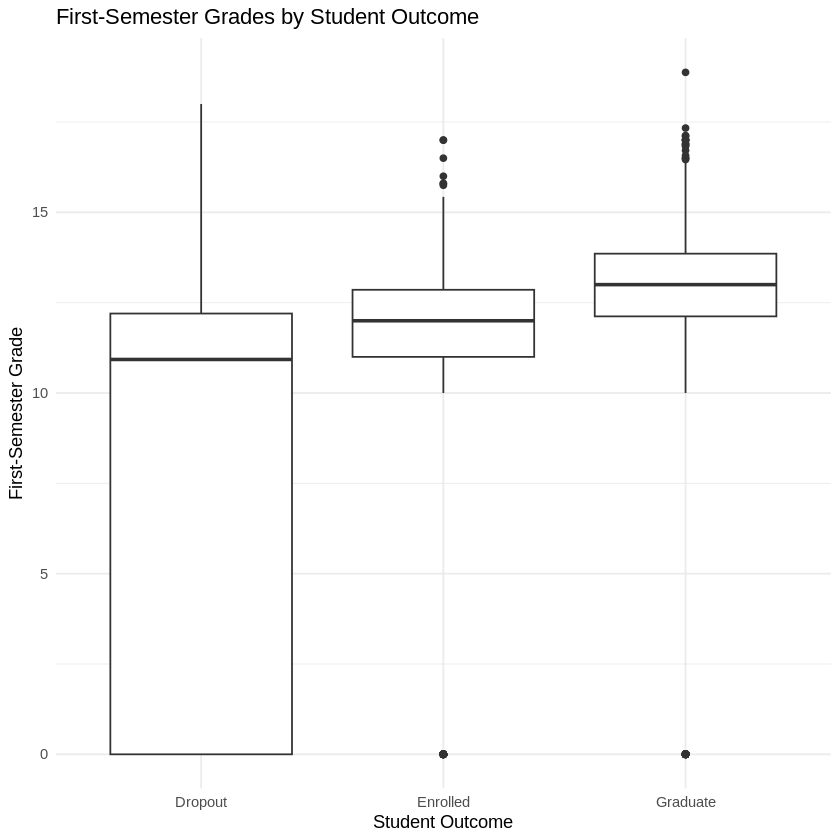

In [36]:
#4.Create the grade boxplot

ggplot(
  academic_progress,
  aes(
    x = target,
    y = curricular_units_1st_sem_grade
  )
) +
  geom_boxplot() +
  labs(
    title = "First-Semester Grades by Student Outcome",
    x = "Student Outcome",
    y = "First-Semester Grade"
  ) +
  theme_minimal()

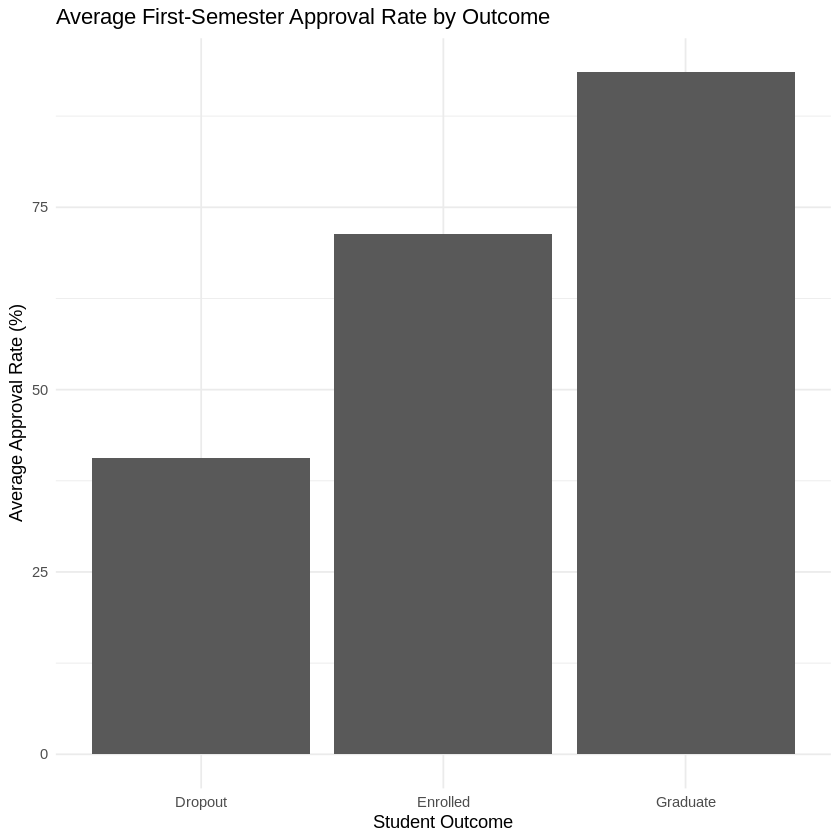

In [37]:
#5.Create the approval-rate chart

ggplot(
  academic_summary,
  aes(
    x = target,
    y = mean_approval_rate
  )
) +
  geom_col() +
  labs(
    title = "Average First-Semester Approval Rate by Outcome",
    x = "Student Outcome",
    y = "Average Approval Rate (%)"
  ) +
  theme_minimal()

In [38]:
#6.Run a Kruskal-Wallis test

grade_test <- kruskal.test(
  curricular_units_1st_sem_grade ~ target,
  data = academic_progress
)

grade_test


	Kruskal-Wallis rank sum test

data:  curricular_units_1st_sem_grade by target
Kruskal-Wallis chi-squared = 1094.2, df = 2, p-value < 2.2e-16


## Validation Results

The academic-progress data passed the main logical quality checks.

There were:

- 0 negative enrolled-unit values
- 0 negative approved-unit values
- 0 cases where approved units exceeded enrolled units
- 0 calculated approval rates outside the valid range of 0 to 1

There were 180 missing approval-rate values. These values occurred because 180 students had zero first-semester enrolled curricular units. The approval rate was not calculated for those students because dividing by zero would be invalid.

These records were retained in the dataset, but they were excluded only from calculations that required an approval rate.

## Visualization Results

The first-semester grade boxplot showed different grade patterns across the three student outcome groups.

Students in the Dropout group had the lowest typical first-semester grades and the greatest variation. This group also contained many grade values equal to zero.

Students in the Enrolled group generally had higher first-semester grades than students in the Dropout group but lower grades than students in the Graduate group.

Students in the Graduate group had the highest typical first-semester grades. Their grade distribution was more concentrated in the higher portion of the observed range.

The approval-rate bar chart showed the same general pattern:

- The Dropout group had the lowest average first-semester approval rate.
- The Enrolled group had a higher average approval rate.
- The Graduate group had the highest average approval rate.

This suggests that students with different later outcomes also had noticeably different first-semester academic-progress patterns.

## Practical Interpretation

First-semester course approval and grades appear to differ across students who later dropped out, remained enrolled, or graduated.

The Graduate group showed the strongest average first-semester academic progress, while the Dropout group showed the lowest average progress.

These patterns may help student success staff identify academic areas that deserve further investigation, such as course completion, tutoring access, advising, and early-semester support.

However, the results should be interpreted as group-level patterns. They should not be used to assume that one student will drop out or graduate based only on a first-semester grade or approval rate.

## Limitation

This analysis is retrospective because first-semester performance is being compared with outcomes recorded later.

The observed differences do not prove that first-semester grades or approval rates caused students to drop out or graduate.

Other academic, financial, personal, and institutional circumstances may also affect student outcomes.

The 180 students with zero enrolled units did not receive an approval-rate value because the rate could not be calculated. This should be considered when interpreting the group averages.

In [39]:
academic_summary

target,sample_size,mean_grade,median_grade,mean_units_enrolled,mean_units_approved,mean_approval_rate,median_approval_rate
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Dropout,1421,7.256656,10.92857,5.821253,2.551724,40.59937,40
Enrolled,794,11.125257,12.00000,5.964736,4.318640,71.35339,80
Graduate,2209,12.643655,13.00000,6.669534,6.232232,93.49675,100


In [40]:
grade_test


	Kruskal-Wallis rank sum test

data:  curricular_units_1st_sem_grade by target
Kruskal-Wallis chi-squared = 1094.2, df = 2, p-value < 2.2e-16


## Academic Progress Results

The academic-progress analysis compared first-semester performance across students who later dropped out, remained enrolled, or graduated.

### Dropout Group

The Dropout group contained 1,421 students.

Their average first-semester grade was approximately 7.26, and their median grade was approximately 10.93.

Students in this group enrolled in an average of approximately 5.82 curricular units and approved an average of approximately 2.55 units.

Their average first-semester approval rate was approximately 40.60%, and the median approval rate was 40%.

### Enrolled Group

The Enrolled group contained 794 students.

Their average first-semester grade was approximately 11.13, and their median grade was 12.00.

Students in this group enrolled in an average of approximately 5.96 curricular units and approved an average of approximately 4.32 units.

Their average first-semester approval rate was approximately 71.35%, and the median approval rate was 80%.

### Graduate Group

The Graduate group contained 2,209 students.

Their average first-semester grade was approximately 12.64, and their median grade was 13.00.

Students in this group enrolled in an average of approximately 6.67 curricular units and approved an average of approximately 6.23 units.

Their average first-semester approval rate was approximately 93.50%, and the median approval rate was 100%.

## Statistical Test Results

A Kruskal-Wallis test was used because the first-semester grade distribution contained many zero values and was not normally shaped.

The test produced:

- Kruskal-Wallis chi-squared statistic: 1094.2
- Degrees of freedom: 2
- P-value: less than 2.2 × 10⁻¹⁶

This provides very strong statistical evidence that first-semester grade distributions differed across the Dropout, Enrolled, and Graduate groups.

The test shows that at least one group differed from the others, but it does not identify every specific pairwise difference by itself.

## Practical Interpretation

The three outcome groups showed clearly different first-semester academic-progress patterns.

Students who later graduated had the highest average grade, the highest number of approved units, and the highest approval rate.

Students who remained enrolled had results between the Graduate and Dropout groups.

Students who later dropped out had the lowest average grade, approved the fewest units, and had the lowest approval rate.

The difference in average approval rates was especially large:

- Dropout: approximately 40.60%
- Enrolled: approximately 71.35%
- Graduate: approximately 93.50%

These results suggest that first-semester course completion and grades may be useful areas for student-success staff to monitor at the group level.

The findings may support further review of tutoring, academic advising, course planning, and early-semester support services.

## Limitation

This analysis is retrospective because it compares first-semester performance with outcomes recorded later.

The observed differences do not prove that first-semester grades or approval rates caused students to drop out or graduate.

The Kruskal-Wallis test confirms that the groups differ overall, but it does not explain why the differences occurred.

Other factors, including financial circumstances, work responsibilities, health, family obligations, academic preparation, and access to support services, may also influence student outcomes.

The results should not be used to automatically label an individual student as likely to drop out or graduate.

In [41]:
#1. Create program outcome summaries

program_summary <- students |>
  group_by(course) |>
  summarise(
    sample_size = n(),

    dropout_count =
      sum(target == "Dropout"),

    enrolled_count =
      sum(target == "Enrolled"),

    graduate_count =
      sum(target == "Graduate"),

    dropout_percentage =
      mean(target == "Dropout") * 100,

    enrolled_percentage =
      mean(target == "Enrolled") * 100,

    graduate_percentage =
      mean(target == "Graduate") * 100,

    .groups = "drop"
  ) |>
  arrange(desc(dropout_percentage))

program_summary

course,sample_size,dropout_count,enrolled_count,graduate_count,dropout_percentage,enrolled_percentage,graduate_percentage
<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
33,12,8,3,1,66.66667,25.000000,8.333333
9130,141,78,21,42,55.31915,14.893617,29.787234
9119,170,92,64,14,54.11765,37.647059,8.235294
9991,268,136,54,78,50.74627,20.149254,29.104478
9853,192,85,50,57,44.27083,26.041667,29.687500
9003,210,86,37,87,40.95238,17.619048,41.428571
9556,86,33,17,36,38.37209,19.767442,41.860465
171,215,82,37,96,38.13953,17.209302,44.651163
9254,252,96,41,115,38.09524,16.269841,45.634921


In [42]:
#2. Validate the data

students |>
  summarise(
    missing_course =
      sum(is.na(course)),

    missing_target =
      sum(is.na(target)),

    unexpected_target_values =
      sum(
        !target %in% c(
          "Dropout",
          "Enrolled",
          "Graduate"
        )
      ),

    number_of_programs =
      n_distinct(course)
  )

missing_course,missing_target,unexpected_target_values,number_of_programs
<int>,<int>,<int>,<int>
0,0,0,17


In [43]:
#3. Flag small programs

program_summary <- program_summary |>
  mutate(
    sample_size_warning =
      if_else(
        sample_size < 30,
        "Small sample — interpret carefully",
        "Adequate sample size"
      )
  )

program_summary

course,sample_size,dropout_count,enrolled_count,graduate_count,dropout_percentage,enrolled_percentage,graduate_percentage,sample_size_warning
<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
33,12,8,3,1,66.66667,25.000000,8.333333,Small sample — interpret carefully
9130,141,78,21,42,55.31915,14.893617,29.787234,Adequate sample size
9119,170,92,64,14,54.11765,37.647059,8.235294,Adequate sample size
9991,268,136,54,78,50.74627,20.149254,29.104478,Adequate sample size
9853,192,85,50,57,44.27083,26.041667,29.687500,Adequate sample size
9003,210,86,37,87,40.95238,17.619048,41.428571,Adequate sample size
9556,86,33,17,36,38.37209,19.767442,41.860465,Adequate sample size
171,215,82,37,96,38.13953,17.209302,44.651163,Adequate sample size
9254,252,96,41,115,38.09524,16.269841,45.634921,Adequate sample size


In [44]:
#4. Show the five highest dropout percentages

top_five_programs <- program_summary |>
  slice_head(n = 5)

top_five_programs

course,sample_size,dropout_count,enrolled_count,graduate_count,dropout_percentage,enrolled_percentage,graduate_percentage,sample_size_warning
<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
33,12,8,3,1,66.66667,25.00000,8.333333,Small sample — interpret carefully
9130,141,78,21,42,55.31915,14.89362,29.787234,Adequate sample size
9119,170,92,64,14,54.11765,37.64706,8.235294,Adequate sample size
9991,268,136,54,78,50.74627,20.14925,29.104478,Adequate sample size
9853,192,85,50,57,44.27083,26.04167,29.687500,Adequate sample size


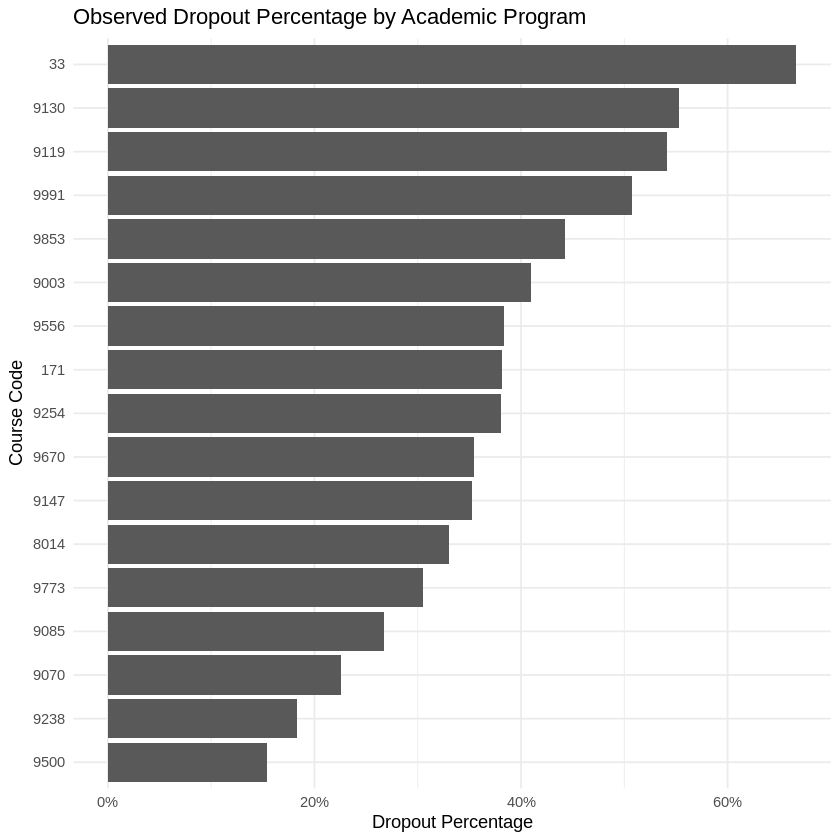

In [45]:
#5.

ggplot(
  program_summary,
  aes(
    x = reorder(
      as.factor(course),
      dropout_percentage
    ),
    y = dropout_percentage
  )
) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Observed Dropout Percentage by Academic Program",
    x = "Course Code",
    y = "Dropout Percentage"
  ) +
  scale_y_continuous(
    labels = scales::label_percent(scale = 1)
  ) +
  theme_minimal()

In [46]:
#6. Calculate confidence intervals

program_summary <- program_summary |>
  mutate(
    dropout_proportion =
      dropout_count / sample_size,

    standard_error =
      sqrt(
        dropout_proportion *
          (1 - dropout_proportion) /
          sample_size
      ),

    confidence_low =
      pmax(
        0,
        dropout_proportion -
          1.96 * standard_error
      ) * 100,

    confidence_high =
      pmin(
        1,
        dropout_proportion +
          1.96 * standard_error
      ) * 100
  )

program_summary

course,sample_size,dropout_count,enrolled_count,graduate_count,dropout_percentage,enrolled_percentage,graduate_percentage,sample_size_warning,dropout_proportion,standard_error,confidence_low,confidence_high
<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
33,12,8,3,1,66.66667,25.000000,8.333333,Small sample — interpret carefully,0.6666667,0.13608276,39.99445,93.33889
9130,141,78,21,42,55.31915,14.893617,29.787234,Adequate sample size,0.5531915,0.04186865,47.11289,63.52540
9119,170,92,64,14,54.11765,37.647059,8.235294,Adequate sample size,0.5411765,0.03821799,46.62692,61.60837
9991,268,136,54,78,50.74627,20.149254,29.104478,Adequate sample size,0.5074627,0.03053896,44.76063,56.73190
9853,192,85,50,57,44.27083,26.041667,29.687500,Adequate sample size,0.4427083,0.03584673,37.24487,51.29679
9003,210,86,37,87,40.95238,17.619048,41.428571,Adequate sample size,0.4095238,0.03393369,34.30138,47.60338
9556,86,33,17,36,38.37209,19.767442,41.860465,Adequate sample size,0.3837209,0.05243813,28.09422,48.64997
171,215,82,37,96,38.13953,17.209302,44.651163,Adequate sample size,0.3813953,0.03312646,31.64675,44.63232
9254,252,96,41,115,38.09524,16.269841,45.634921,Adequate sample size,0.3809524,0.03059124,32.09935,44.09112


In [47]:
program_summary

course,sample_size,dropout_count,enrolled_count,graduate_count,dropout_percentage,enrolled_percentage,graduate_percentage,sample_size_warning,dropout_proportion,standard_error,confidence_low,confidence_high
<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
33,12,8,3,1,66.66667,25.000000,8.333333,Small sample — interpret carefully,0.6666667,0.13608276,39.99445,93.33889
9130,141,78,21,42,55.31915,14.893617,29.787234,Adequate sample size,0.5531915,0.04186865,47.11289,63.52540
9119,170,92,64,14,54.11765,37.647059,8.235294,Adequate sample size,0.5411765,0.03821799,46.62692,61.60837
9991,268,136,54,78,50.74627,20.149254,29.104478,Adequate sample size,0.5074627,0.03053896,44.76063,56.73190
9853,192,85,50,57,44.27083,26.041667,29.687500,Adequate sample size,0.4427083,0.03584673,37.24487,51.29679
9003,210,86,37,87,40.95238,17.619048,41.428571,Adequate sample size,0.4095238,0.03393369,34.30138,47.60338
9556,86,33,17,36,38.37209,19.767442,41.860465,Adequate sample size,0.3837209,0.05243813,28.09422,48.64997
171,215,82,37,96,38.13953,17.209302,44.651163,Adequate sample size,0.3813953,0.03312646,31.64675,44.63232
9254,252,96,41,115,38.09524,16.269841,45.634921,Adequate sample size,0.3809524,0.03059124,32.09935,44.09112


In [48]:
top_five_programs

course,sample_size,dropout_count,enrolled_count,graduate_count,dropout_percentage,enrolled_percentage,graduate_percentage,sample_size_warning
<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
33,12,8,3,1,66.66667,25.00000,8.333333,Small sample — interpret carefully
9130,141,78,21,42,55.31915,14.89362,29.787234,Adequate sample size
9119,170,92,64,14,54.11765,37.64706,8.235294,Adequate sample size
9991,268,136,54,78,50.74627,20.14925,29.104478,Adequate sample size
9853,192,85,50,57,44.27083,26.04167,29.687500,Adequate sample size


In [49]:
students |>
  summarise(
    missing_course = sum(is.na(course)),
    missing_target = sum(is.na(target)),
    unexpected_target_values = sum(
      !target %in% c("Dropout", "Enrolled", "Graduate")
    ),
    number_of_programs = n_distinct(course)
  )

missing_course,missing_target,unexpected_target_values,number_of_programs
<int>,<int>,<int>,<int>
0,0,0,17


## Program Support Prioritization Results

The program-level analysis included 17 academic programs.

### Validation Results

The program data passed the main validation checks.

There were:

- 0 missing course values
- 0 missing target values
- 0 unexpected student-outcome values
- 17 distinct academic programs

The expected outcome categories were:

- Dropout
- Enrolled
- Graduate

Programs with fewer than 30 students were flagged because percentages from very small groups may be unstable.

## Highest Observed Dropout Percentages

The five programs with the highest observed dropout percentages were:

### Course 33

- Sample size: 12 students
- Dropout count: 8 students
- Dropout percentage: approximately 66.67%
- Enrolled percentage: 25.00%
- Graduation percentage: approximately 8.33%
- Approximate 95% confidence interval: 39.99% to 93.34%

Course 33 had the highest observed dropout percentage. However, it included only 12 students and was flagged as a small sample.

Because the confidence interval is very wide, this result is uncertain and should be interpreted carefully.

### Course 9130

- Sample size: 141 students
- Dropout count: 78 students
- Dropout percentage: approximately 55.32%
- Enrolled percentage: approximately 14.89%
- Graduation percentage: approximately 29.79%
- Approximate 95% confidence interval: 47.11% to 63.53%

Course 9130 had the highest dropout percentage among the programs with an adequate sample size.

### Course 9119

- Sample size: 170 students
- Dropout count: 92 students
- Dropout percentage: approximately 54.12%
- Enrolled percentage: approximately 37.65%
- Graduation percentage: approximately 8.24%
- Approximate 95% confidence interval: 46.63% to 61.61%

Course 9119 had the second-highest dropout percentage among programs with an adequate sample size.

It also had a particularly low graduation percentage of approximately 8.24%.

### Course 9991

- Sample size: 268 students
- Dropout count: 136 students
- Dropout percentage: approximately 50.75%
- Enrolled percentage: approximately 20.15%
- Graduation percentage: approximately 29.10%
- Approximate 95% confidence interval: 44.76% to 56.73%

Course 9991 had the third-highest dropout percentage among programs with an adequate sample size.

### Course 9853

- Sample size: 192 students
- Dropout count: 85 students
- Dropout percentage: approximately 44.27%
- Enrolled percentage: approximately 26.04%
- Graduation percentage: approximately 29.69%
- Approximate 95% confidence interval: 37.24% to 51.30%

Course 9853 also showed a relatively high dropout percentage and may deserve further review.

## Decision Supported

Course 33 should not automatically be treated as the highest-priority program because its result is based on only 12 students.

Among programs with adequate sample sizes, the strongest priorities for further review are:

1. Course 9130
2. Course 9119
3. Course 9991
4. Course 9853

These programs had the highest observed dropout percentages among groups with at least 30 students.

College administrators could investigate whether students in these programs face issues involving:

- Academic advising
- Tutoring availability
- Course scheduling
- Curriculum difficulty
- Financial barriers
- Student workload
- Academic preparation
- Access to support services

The results help identify where additional investigation may be useful. They do not prove which type of support is needed.

## Practical Interpretation

The program-level dropout percentages varied considerably.

Some programs had dropout percentages above 50%, while other programs had much lower percentages.

Course 9130 had an observed dropout percentage of approximately 55.32%, and course 9119 had a percentage of approximately 54.12%. These results suggest that these programs may deserve closer review.

The ranking should be considered together with sample size and confidence intervals. A percentage based on a small number of students is less stable than a similar percentage based on hundreds of students.

For example, course 33 had the highest percentage, but its confidence interval ranged from approximately 39.99% to 93.34%. This wide range reflects the uncertainty caused by its small sample.

## Limitation

This analysis identifies associations between academic programs and student outcomes. It does not prove that the programs themselves caused students to drop out.

Programs may serve students with different:

- Academic preparation levels
- Financial circumstances
- Employment responsibilities
- Family obligations
- Ages
- Enrollment patterns
- Personal circumstances

The course codes also need to be matched with official program names before results are presented to college staff.

The ranking should not be used to punish programs, faculty members, or students. It should be used to guide further investigation and possible support planning.

In [50]:
#1. Basic dataset audit

data_quality_summary <- tibble(
  observations = nrow(students),
  variables = ncol(students),
  total_missing_values = sum(is.na(students)),
  duplicate_rows = sum(duplicated(students))
)

data_quality_summary

observations,variables,total_missing_values,duplicate_rows
<int>,<int>,<int>,<int>
4424,37,0,0


In [51]:
#2. Missing values by variable

missing_summary <- students |>
  summarise(
    across(
      everything(),
      ~ sum(is.na(.))
    )
  ) |>
  pivot_longer(
    cols = everything(),
    names_to = "variable",
    values_to = "missing_count"
  ) |>
  mutate(
    missing_percentage =
      missing_count / nrow(students) * 100
  ) |>
  arrange(desc(missing_count))

missing_summary

variable,missing_count,missing_percentage
<chr>,<int>,<dbl>
marital_status,0,0
application_mode,0,0
application_order,0,0
course,0,0
daytime_evening_attendance,0,0
previous_qualification,0,0
previous_qualification_grade,0,0
nacionality,0,0
mothers_qualification,0,0


In [52]:
#3. Check category values

category_checks <- tibble(
  invalid_target =
    sum(
      !students$target %in%
        c("Dropout", "Enrolled", "Graduate")
    ),

  invalid_tuition_status =
    sum(
      !students$tuition_fees_up_to_date %in%
        c(0, 1)
    ),

  invalid_debtor_status =
    sum(
      !students$debtor %in%
        c(0, 1)
    ),

  invalid_scholarship_status =
    sum(
      !students$scholarship_holder %in%
        c(0, 1)
    )
)

category_checks

invalid_target,invalid_tuition_status,invalid_debtor_status,invalid_scholarship_status
<int>,<int>,<int>,<int>
0,0,0,0


In [53]:
#4. Check academic logic

academic_checks <- tibble(
  negative_enrolled =
    sum(
      students$curricular_units_1st_sem_enrolled < 0
    ),

  negative_approved =
    sum(
      students$curricular_units_1st_sem_approved < 0
    ),

  approved_greater_than_enrolled =
    sum(
      students$curricular_units_1st_sem_approved >
        students$curricular_units_1st_sem_enrolled
    ),

  negative_grade =
    sum(
      students$curricular_units_1st_sem_grade < 0
    ),

  zero_first_semester_grade =
    sum(
      students$curricular_units_1st_sem_grade == 0
    ),

  zero_enrolled_units =
    sum(
      students$curricular_units_1st_sem_enrolled == 0
    )
)

academic_checks

negative_enrolled,negative_approved,approved_greater_than_enrolled,negative_grade,zero_first_semester_grade,zero_enrolled_units
<int>,<int>,<int>,<int>,<int>,<int>
0,0,0,0,718,180


In [54]:
#5. Create an issue summary table

issue_summary <- tibble(
  issue = c(
    "Missing values",
    "Duplicate rows",
    "Invalid target values",
    "Invalid tuition codes",
    "Invalid debtor codes",
    "Invalid scholarship codes",
    "Negative enrolled units",
    "Negative approved units",
    "Approved units exceed enrolled units",
    "Negative grades"
  ),

  issue_count = c(
    sum(is.na(students)),
    sum(duplicated(students)),
    category_checks$invalid_target,
    category_checks$invalid_tuition_status,
    category_checks$invalid_debtor_status,
    category_checks$invalid_scholarship_status,
    academic_checks$negative_enrolled,
    academic_checks$negative_approved,
    academic_checks$approved_greater_than_enrolled,
    academic_checks$negative_grade
  )
)

issue_summary

issue,issue_count
<chr>,<int>
Missing values,0
Duplicate rows,0
Invalid target values,0
Invalid tuition codes,0
Invalid debtor codes,0
Invalid scholarship codes,0
Negative enrolled units,0
Negative approved units,0
Approved units exceed enrolled units,0


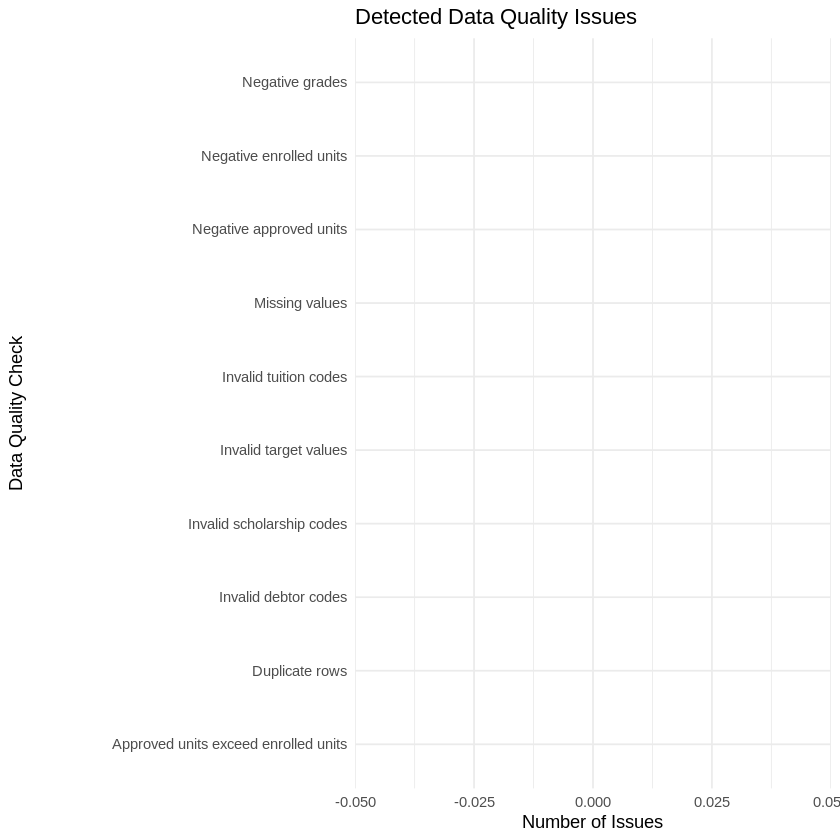

In [55]:
#6. Create the issue chart

ggplot(
  issue_summary,
  aes(
    x = reorder(issue, issue_count),
    y = issue_count
  )
) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Detected Data Quality Issues",
    x = "Data Quality Check",
    y = "Number of Issues"
  ) +
  theme_minimal()

In [56]:
#7. Calculate records affected by major issues

students_with_flags <- students |>
  mutate(
    quality_issue =
      if_any(
        everything(),
        is.na
      ) |
      duplicated(students) |
      !target %in%
        c("Dropout", "Enrolled", "Graduate") |
      !tuition_fees_up_to_date %in%
        c(0, 1) |
      !debtor %in%
        c(0, 1) |
      !scholarship_holder %in%
        c(0, 1) |
      curricular_units_1st_sem_enrolled < 0 |
      curricular_units_1st_sem_approved < 0 |
      curricular_units_1st_sem_approved >
        curricular_units_1st_sem_enrolled |
      curricular_units_1st_sem_grade < 0
  )

In [57]:
#8. Calculate readiness result and quality score

records_affected <- sum(
  students_with_flags$quality_issue
)

records_affected_percentage <-
  records_affected / nrow(students) * 100

data_quality_score <-
  100 - records_affected_percentage

readiness_result <- case_when(
  records_affected == 0 ~
    "Ready for analysis",

  records_affected_percentage <= 5 ~
    "Ready with warnings",

  TRUE ~
    "Cleaning required"
)

quality_result <- tibble(
  records_affected = records_affected,
  records_affected_percentage =
    records_affected_percentage,
  data_quality_score =
    data_quality_score,
  readiness_result =
    readiness_result
)

quality_result

records_affected,records_affected_percentage,data_quality_score,readiness_result
<int>,<dbl>,<dbl>,<chr>
0,0,100,Ready for analysis


In [58]:
data_quality_summary

observations,variables,total_missing_values,duplicate_rows
<int>,<int>,<int>,<int>
4424,37,0,0


In [59]:
category_checks

invalid_target,invalid_tuition_status,invalid_debtor_status,invalid_scholarship_status
<int>,<int>,<int>,<int>
0,0,0,0


In [60]:
academic_checks

negative_enrolled,negative_approved,approved_greater_than_enrolled,negative_grade,zero_first_semester_grade,zero_enrolled_units
<int>,<int>,<int>,<int>,<int>,<int>
0,0,0,0,718,180


In [61]:
issue_summary

issue,issue_count
<chr>,<int>
Missing values,0
Duplicate rows,0
Invalid target values,0
Invalid tuition codes,0
Invalid debtor codes,0
Invalid scholarship codes,0
Negative enrolled units,0
Negative approved units,0
Approved units exceed enrolled units,0


In [62]:
quality_result

records_affected,records_affected_percentage,data_quality_score,readiness_result
<int>,<dbl>,<dbl>,<chr>
0,0,100,Ready for analysis


## Data Quality Audit Results

The Data Quality Audit examined the student dataset for missing values, duplicate records, invalid category codes, negative academic values, and logical inconsistencies.

## Basic Dataset Summary

The dataset contained:

- 4,424 observations
- 37 variables
- 0 missing values
- 0 completely duplicated rows

These results show that the dataset was complete based on the missing-value and duplicate-row checks.

## Category Validation Results

The category checks found:

- 0 invalid target values
- 0 invalid tuition-status codes
- 0 invalid debtor-status codes
- 0 invalid scholarship-status codes

The target variable contained only the expected categories:

- Dropout
- Enrolled
- Graduate

The financial indicator variables contained only the expected binary codes of 0 and 1.

## Academic Logic Results

The academic consistency checks found:

- 0 negative enrolled-unit values
- 0 negative approved-unit values
- 0 cases where approved units exceeded enrolled units
- 0 negative first-semester grades

The audit also identified:

- 718 students with a first-semester grade of zero
- 180 students with zero first-semester enrolled units

These zero values were not automatically classified as errors.

A zero grade may represent a meaningful academic result, especially because the earlier analysis found that all 718 students with zero grades also approved zero first-semester units.

The 180 students with zero enrolled units could not receive an approval-rate value because division by zero is not valid. Those records were retained in the dataset.

## Issue Summary

The formal issue summary detected:

- 0 missing values
- 0 duplicate rows
- 0 invalid target values
- 0 invalid tuition codes
- 0 invalid debtor codes
- 0 invalid scholarship codes
- 0 negative enrolled-unit values
- 0 negative approved-unit values
- 0 cases where approved units exceeded enrolled units
- 0 negative grades

Because every formal issue count was zero, the data-quality chart contained no visible bars. This is an expected result rather than a charting error.

## Readiness Result

The audit found:

- Records affected by documented major issues: 0
- Percentage of records affected: 0%
- Data-quality score: 100
- Readiness result: Ready for analysis

Based on the documented checks, the dataset is ready for the planned statistical analyses.

## Practical Interpretation

The dataset passed all major automated quality checks included in this audit.

The absence of missing values, duplicate rows, invalid category codes, negative values, and logical academic inconsistencies supports using the dataset for the project’s descriptive, comparison, and modeling analyses.

The zero-grade and zero-enrollment values should remain in the dataset because they may represent meaningful student records rather than missing information.

The audit also demonstrates why unusual values should be investigated before they are removed. A value can look unusual without being incorrect.

## Limitation

A data-quality score of 100 does not prove that every value in the dataset is correct.

Automated checks can detect documented problems such as missing values, invalid codes, and logical inconsistencies. However, they may not detect values that are incorrect but still fall within an acceptable range.

The audit also depends on the documented coding rules and expected variable ranges being accurate.

Additional review may still be needed before the results are used for important institutional decisions.

# Part 9: Plan the Three Additional Skills

The following table summarizes the planning for the three additional skills developed for the Industry Statistical Assistant project.

| Item | Skill 1 | Skill 2 | Skill 3 |
|---|---|---|---|
| **Skill name** | Academic Progress Analysis | Program Support Prioritization | Data Quality Audit |
| **User question** | How does first-semester academic progress differ among students who dropped out, remained enrolled, or graduated? | Which academic programs have the highest observed dropout percentages and may require further review? | Are missing values, duplicate records, invalid codes, or unusual academic values affecting the reliability of the student analysis? |
| **Intended user** | College student success coordinator or academic advisor | College administrator, retention coordinator, or program director | Data analyst, student success coordinator, or academic administrator |
| **Decision supported** | Helps determine whether first-semester grades, approved units, and approval rates should be reviewed when planning early academic support. | Helps determine which academic programs should be reviewed first for possible advising, tutoring, scheduling, or retention support needs. | Helps determine whether the dataset is ready for statistical analysis or whether additional cleaning and investigation are required. |
| **Required inputs** | `target`, `curricular_units_1st_sem_enrolled`, `curricular_units_1st_sem_approved`, `curricular_units_1st_sem_grade` | `course`, `target` | All dataset variables, with special attention to `target`, `course`, academic-progress variables, and financial-status variables |
| **Method** | Create an approval-rate variable, calculate group summary statistics, create visualizations, and use a Kruskal-Wallis test to compare grade distributions across the three outcome groups. | Calculate program sample sizes, dropout counts, dropout percentages, enrolled percentages, graduation percentages, confidence intervals, and rank programs by dropout percentage. | Count missing values and duplicates, check category codes, test academic logic, summarize detected issues, calculate records affected, and assign a data-readiness result. |
| **Output** | Group summary table, mean and median grades, mean enrolled and approved units, approval rates, boxplot, bar chart, statistical test, interpretation, and limitation | Ranked program table, dropout counts and percentages, confidence intervals, small-sample warnings, horizontal bar chart, decision priorities, interpretation, and limitation | Dataset summary, missing-value table, category checks, academic logic checks, issue table, issue chart, data-quality score, readiness result, interpretation, and limitation |
| **Validation** | Confirm required variables exist, academic variables are numeric, values are nonnegative, approved units do not exceed enrolled units, approval rates remain between 0 and 1, and division by zero is prevented. | Confirm course and target variables exist, target categories are valid, course values are available, sample sizes are sufficient, percentages are calculated within programs, and small programs are flagged. | Confirm the dataset exists, required variables are present, category values match documented codes, academic values are logically consistent, missing values are distinguished from valid zero values, and original records are not silently changed. |
| **Limitation** | The analysis is retrospective and does not prove that first-semester performance caused later student outcomes. | A high dropout percentage does not prove that a program caused students to leave or that the program is low quality. | Passing automated checks does not prove that every value is correct because some incorrect values may still fall within acceptable ranges. |

## Major Changes During Development

The original plan included a Financial Risk skill. During development, this idea was replaced with the Data Quality Audit skill because financial-risk analysis overlapped with the required two-group comparison involving tuition status.

The Program Support Prioritization skill was also refined to include:

- A minimum sample-size warning
- Approximate 95% confidence intervals
- A warning that program rankings should not be interpreted as measures of program quality

The Academic Progress Analysis skill was refined to use a Kruskal-Wallis test instead of a standard one-way analysis of variance because the grade distribution contained many zero values and was not normally shaped.

# Part 10: Build the R Analysis

All statistical calculations for this project were completed in R.

The project includes:

- Data import
- Data cleaning
- Variable preparation
- Explore analysis
- Compare analysis
- Statistical model
- Academic Progress Analysis
- Program Support Prioritization
- Data Quality Audit
- Validation checks
- Visualizations
- Interpretation-ready results

## R File Organization

The R code will be organized into the following files:

```text
R/
├── import_data.R
├── clean_data.R
├── explore.R
├── compare.R
├── model.R
├── academic_progress_analysis.R
├── program_support_prioritization.R
└── data_quality_audit.R
```

Each file has a specific purpose:

| R file | Purpose |
|---|---|
| `import_data.R` | Loads packages and imports the dataset. |
| `clean_data.R` | Cleans variable names and checks missing values and duplicates. |
| `explore.R` | Examines the distribution of first-semester grades. |
| `compare.R` | Compares dropout percentages by tuition-payment status. |
| `model.R` | Builds and evaluates the logistic regression model. |
| `academic_progress_analysis.R` | Compares academic progress across Dropout, Enrolled, and Graduate groups. |
| `program_support_prioritization.R` | Ranks academic programs by observed dropout percentage. |
| `data_quality_audit.R` | Checks missing values, duplicates, invalid codes, and logical inconsistencies. |

## Code Quality

The R code was written to be:

- Organized
- Readable
- Reproducible
- Appropriately commented
- Based on clear object names
- Able to handle missing values
- Able to return useful validation results

A fixed random seed was used for the model train-test split:

```r
set.seed(123)
```

This allows the same train-test split to be reproduced.

## Validation

Validation checks were included throughout the analysis.

The code checks for:

- Missing values
- Duplicate rows
- Invalid target values
- Invalid binary codes
- Negative academic values
- Approved units exceeding enrolled units
- Division by zero
- Small program sample sizes

The code reports problems instead of silently deleting records.

## Results

All statistical results, tables, and visualizations shown in the project were produced directly from R.

No statistical results were manually calculated.

Important R result objects include:

```r
academic_summary
program_summary
data_quality_summary
category_checks
academic_checks
issue_summary
quality_result
```

The R analysis is complete and produces results that are ready to use in the final report.

# Part 11: Add Validation

Every statistical skill in this project includes validation rules.

Validation is used to confirm that:

- Required variables exist.
- Variables have the correct data type.
- Grouping variables contain the required number of groups.
- Groups contain enough observations.
- Outcome categories are valid.
- Calculations do not divide by zero.
- Model inputs contain the required information.
- Results are not incorrectly described as causal.

When a request is invalid or inappropriate, the analysis should stop and clearly explain the problem instead of returning a misleading result.

## Validation Rules by Skill

| Skill | Example validation rule |
|---|---|
| Explore Data | The selected variable must exist and must be numeric for numeric summary statistics. |
| Compare Two Groups | The grouping variable must contain exactly two valid groups. |
| Statistical Model | The outcome must be appropriate for logistic regression, and prediction inputs must contain all required variables. |
| Academic Progress Analysis | Approved units cannot exceed enrolled units, and approval rates cannot be calculated when enrolled units equal zero. |
| Program Support Prioritization | Programs with fewer than 30 observations must be flagged as small samples. |
| Data Quality Audit | Expected category codes and logical academic relationships must be checked before analysis. |

## Invalid Request Demonstrations

The project demonstrates at least four invalid or inappropriate requests:

1. A selected variable does not exist.
2. A numeric analysis is requested for a categorical variable.
3. A grouping variable does not contain exactly two groups.
4. One comparison group contains too few observations.
5. A causal conclusion is requested from observational data.
6. A model prediction is requested without all required inputs.

The R code below demonstrates how the assistant should stop and explain each problem clearly.

In [63]:
#1. Validation function for missing variables

validate_variable_exists <- function(data, variable_name) {
  if (!variable_name %in% names(data)) {
    stop(
      paste0(
        "Validation error: The selected variable '",
        variable_name,
        "' does not exist in the dataset."
      )
    )
  }

  message(
    paste0(
      "Validation passed: The variable '",
      variable_name,
      "' exists."
    )
  )
}

In [64]:
try(
  validate_variable_exists(
    students,
    "student_income"
  )
)

Error in validate_variable_exists(students, "student_income") : 
  Validation error: The selected variable 'student_income' does not exist in the dataset.


In [65]:
#2. Validation function for numeric variables

validate_numeric_variable <- function(data, variable_name) {
  validate_variable_exists(data, variable_name)

  if (!is.numeric(data[[variable_name]])) {
    stop(
      paste0(
        "Validation error: The selected variable '",
        variable_name,
        "' must be numeric for this analysis."
      )
    )
  }

  message(
    paste0(
      "Validation passed: The variable '",
      variable_name,
      "' is numeric."
    )
  )
}

In [66]:
try(
  validate_numeric_variable(
    students,
    "target"
  )
)

Validation passed: The variable 'target' exists.



Error in validate_numeric_variable(students, "target") : 
  Validation error: The selected variable 'target' must be numeric for this analysis.


In [67]:
#3. Validation function for exactly two groups

validate_two_groups <- function(data, grouping_variable) {
  validate_variable_exists(
    data,
    grouping_variable
  )

  valid_groups <- data[[grouping_variable]] |>
    na.omit() |>
    unique()

  number_of_groups <- length(valid_groups)

  if (number_of_groups != 2) {
    stop(
      paste0(
        "Validation error: The grouping variable must contain exactly two valid groups. ",
        "The selected variable contains ",
        number_of_groups,
        " groups."
      )
    )
  }

  message(
    "Validation passed: The grouping variable contains exactly two groups."
  )
}

In [68]:
try(
  validate_two_groups(
    students,
    "target"
  )
)

Validation passed: The variable 'target' exists.



Error in validate_two_groups(students, "target") : 
  Validation error: The grouping variable must contain exactly two valid groups. The selected variable contains 3 groups.


In [69]:
#4. Validation function for minimum group size

validate_group_size <- function(
  data,
  grouping_variable,
  minimum_size = 30
) {
  validate_variable_exists(
    data,
    grouping_variable
  )

  group_counts <- table(
    data[[grouping_variable]],
    useNA = "no"
  )

  small_groups <- group_counts[
    group_counts < minimum_size
  ]

  if (length(small_groups) > 0) {
    small_group_text <- paste(
      names(small_groups),
      small_groups,
      sep = " = ",
      collapse = ", "
    )

    stop(
      paste0(
        "Validation error: At least one group contains fewer than ",
        minimum_size,
        " observations. ",
        "Small groups: ",
        small_group_text,
        "."
      )
    )
  }

  message(
    "Validation passed: All groups meet the minimum sample-size requirement."
  )
}

In [70]:
try(
  validate_group_size(
    students,
    "course",
    minimum_size = 30
  )
)

Validation passed: The variable 'course' exists.



Error in validate_group_size(students, "course", minimum_size = 30) : 
  Validation error: At least one group contains fewer than 30 observations. Small groups: 33 = 12.


In [71]:
#5. Validation against causal conclusions

validate_causal_request <- function(
  request_text,
  observational_data = TRUE
) {
  causal_words <- c(
    "cause",
    "causes",
    "caused",
    "causing",
    "proves",
    "results in"
  )

  causal_request <- any(
    str_detect(
      str_to_lower(request_text),
      causal_words
    )
  )

  if (observational_data && causal_request) {
    stop(
      paste(
        "Validation error:",
        "This analysis identifies an association.",
        "It does not prove causation because the dataset is observational."
      )
    )
  }

  message(
    "Validation passed: The requested interpretation is appropriate."
  )
}

In [72]:
try(
  validate_causal_request(
    "Prove that unpaid tuition causes students to drop out."
  )
)

Error in validate_causal_request("Prove that unpaid tuition causes students to drop out.") : 
  Validation error: This analysis identifies an association. It does not prove causation because the dataset is observational.


In [73]:
#6. Validate required model prediction inputs

validate_prediction_inputs <- function(
  new_data,
  required_variables
) {
  missing_variables <- setdiff(
    required_variables,
    names(new_data)
  )

  if (length(missing_variables) > 0) {
    stop(
      paste0(
        "Validation error: Prediction cannot be completed. Missing required inputs: ",
        paste(
          missing_variables,
          collapse = ", "
        ),
        "."
      )
    )
  }

  message(
    "Validation passed: All required prediction inputs are present."
  )
}

In [74]:
required_model_inputs <- c(
  "curricular_units_1st_sem_grade",
  "curricular_units_1st_sem_approved",
  "tuition_fees_up_to_date",
  "debtor",
  "scholarship_holder",
  "admission_grade",
  "age_at_enrollment"
)

incomplete_student <- tibble(
  curricular_units_1st_sem_grade = 12,
  curricular_units_1st_sem_approved = 5,
  tuition_fees_up_to_date = 1
)

try(
  validate_prediction_inputs(
    incomplete_student,
    required_model_inputs
  )
)

Error in validate_prediction_inputs(incomplete_student, required_model_inputs) : 
  Validation error: Prediction cannot be completed. Missing required inputs: debtor, scholarship_holder, admission_grade, age_at_enrollment.


## Validation Demonstration Results

The validation tests showed that the assistant does not always return a statistical result.

Instead, it stops when a request is invalid or inappropriate.

The demonstrations produced clear messages for the following situations:

- A requested variable was not found.
- A categorical variable was incorrectly selected for a numeric analysis.
- A grouping variable contained three groups instead of exactly two.
- A program group contained fewer than 30 observations.
- A causal conclusion was requested from observational data.
- A model prediction was requested without all required inputs.

These checks reduce the risk of producing incorrect, misleading, or unsupported results.

The validation functions explain the specific problem and indicate what must be corrected before the analysis can continue.

# Part 12: Select One Implementation Level

## Selected Level: Level 1 — Quarto Statistical Report

For this project, I selected **Level 1: Quarto Statistical Report**.

This level is the best fit for the Industry Statistical Assistant because the project focuses on:

- R
- Statistical analysis
- Reproducibility
- Interpretation
- Validation
- Agent skills
- Responsible use of student data

The final project will present all six skills in one organized Quarto report.

## Why Level 1 Was Selected

Level 1 was selected because the required statistical work has already been completed in R.

The project includes:

1. Explore Data
2. Compare Two Groups
3. Statistical Model
4. Academic Progress Analysis
5. Program Support Prioritization
6. Data Quality Audit

Each skill includes:

- A clear user question
- Required input variables
- An R analysis method
- Validation rules
- Statistical results
- Visualizations when appropriate
- Practical interpretation
- Limitations

The main goal of the project is to create a complete, accurate, and understandable statistical assistant for a college student success coordinator or academic advisor.

A separate API, local application, or multi-page website is not required for this level.

## Required Level 1 Outputs

The final Level 1 project will include:

- One main `.qmd` file
- HTML output
- PDF output
- Dataset section
- Six skill sections
- Visualizations
- Validation examples
- Limitations
- Reflection
- GitHub repository
- README file

## Planned Quarto Report Sections

The final Quarto report will contain the following sections:

1. Project Introduction
2. Industry Problem
3. Intended User
4. Dataset Description
5. Data Import and Cleaning
6. Explore Data
7. Compare Two Groups
8. Statistical Model
9. Academic Progress Analysis
10. Program Support Prioritization
11. Data Quality Audit
12. Validation Demonstrations
13. Limitations and Responsible Use
14. Reflection
15. Conclusion

## Agent Skill Workflow

The Agent Skills will instruct Antigravity how to:

- Identify the requested analysis
- Read the correct `SKILL.md` file
- Validate the user request
- Run the matching R code
- Create the statistical result
- Provide a practical interpretation
- Include a warning or limitation
- Update the correct section of the Quarto report

An example workflow is:

```text
User requests a group comparison
            ↓
Antigravity reads the Compare skill instructions
            ↓
The requested variables are validated
            ↓
The R comparison code is run
            ↓
Statistical results are generated
            ↓
The Compare section of the Quarto report is updated
```

## Planned Project Structure

```text
student-success-statistical-assistant/
├── README.md
├── .gitignore
├── data/
│   └── data.csv
├── R/
│   ├── import_data.R
│   ├── clean_data.R
│   ├── explore.R
│   ├── compare.R
│   ├── model.R
│   ├── academic_progress_analysis.R
│   ├── program_support_prioritization.R
│   └── data_quality_audit.R
├── .agents/
│   └── skills/
│       ├── explore/
│       │   └── SKILL.md
│       ├── compare/
│       │   └── SKILL.md
│       ├── model/
│       │   └── SKILL.md
│       ├── academic-progress/
│       │   └── SKILL.md
│       ├── program-outcomes/
│       │   └── SKILL.md
│       └── data-quality-audit/
│           └── SKILL.md
├── final_report.qmd
├── final_report.html
└── final_report.pdf
```

## Level 1 Completion Goal

The completed project will provide one reproducible Quarto report containing all six skills and their R-generated results.

The report will emphasize:

- Correct statistical methods
- Clear validation messages
- Reproducible R code
- Useful visualizations
- Plain-language interpretations
- Responsible conclusions
- Clear limitations

Level 1 allows the project to focus on the quality and completeness of the statistical assistant rather than adding unnecessary technical complexity.

# Part 13: GitHub Requirements

The complete Industry Statistical Assistant project will be stored in one GitHub repository.

## Repository Name

`student-success-statistical-assistant`

## Required Repository Contents

The repository will include:

- The dataset or instructions for accessing the dataset
- Organized R code
- Six `SKILL.md` files
- The main Quarto source file
- The rendered HTML report
- The rendered PDF report
- A complete `README.md`
- Files required for Level 1: Quarto Statistical Report

## Planned Repository Structure

```text
student-success-statistical-assistant/
├── README.md
├── .gitignore
├── data/
│   └── data.csv
├── R/
│   ├── import_data.R
│   ├── clean_data.R
│   ├── explore.R
│   ├── compare.R
│   ├── model.R
│   ├── academic_progress_analysis.R
│   ├── program_support_prioritization.R
│   └── data_quality_audit.R
├── .agents/
│   └── skills/
│       ├── explore/
│       │   └── SKILL.md
│       ├── compare/
│       │   └── SKILL.md
│       ├── model/
│       │   └── SKILL.md
│       ├── academic-progress/
│       │   └── SKILL.md
│       ├── program-outcomes/
│       │   └── SKILL.md
│       └── data-quality-audit/
│           └── SKILL.md
├── images/
│   └── project-screenshot.png
├── final_report.qmd
├── final_report.html
└── final_report.pdf
```

## Planned GitHub Commits

The repository will contain at least six meaningful commits.

Planned commit messages include:

1. `Create project structure and add dataset`
2. `Add data import and cleaning scripts`
3. `Add Explore and Compare skills`
4. `Add logistic regression model skill`
5. `Add three student-designed skills`
6. `Add validation functions and test cases`
7. `Create Quarto statistical report`
8. `Add README and project screenshot`
9. `Render final HTML and PDF outputs`
10. `Review project structure and documentation`

The commit messages will describe the work completed rather than using unclear messages such as “Update,” “Changes,” or “Final.”

## Repository Safety

The repository will not contain:

- Passwords
- API keys
- Private credentials
- Confidential student information
- Personally identifiable information
- Unnecessary large files

The dataset used for this project is a public educational dataset and does not include student names or direct personal identifiers.

The instructor’s GitHub username will be added as a collaborator when required.

---

# Part 14: README Requirements

The `README.md` file will provide an overview of the project and instructions for viewing or reproducing the analysis.

## Project Title

**Student Success Statistical Assistant**

## Student Name

Ivetsy Morejon

## Selected Implementation Level

**Level 1: Quarto Statistical Report**

## Industry

Higher Education

## Intended User

The intended user is a college student success coordinator or academic advisor.

## Problem

Colleges need to understand patterns associated with student dropout and academic success so they can identify areas where students may benefit from earlier support.

## Decision Supported

The assistant supports decisions about:

- Academic advising
- Tutoring and academic support
- Financial-support review
- Program-level review
- Student-retention planning
- Data readiness and reliability

The results are designed to guide further investigation and support planning. They should not be used to automatically label students or deny services.

## Dataset Source

The project uses the UCI Machine Learning Repository dataset:

**Predict Students’ Dropout and Academic Success**

The dataset contains:

- 4,424 student records
- 37 variables
- 1,421 Dropout outcomes
- 794 Enrolled outcomes
- 2,209 Graduate outcomes

One row represents one college student.

## Six-Skill Summary

| Skill | User Question | Method | Main Output | Decision Supported |
|---|---|---|---|---|
| **Explore** | What does the distribution of first-semester grades look like? | Descriptive statistics, histogram, boxplot, and zero-value investigation | Grade distribution, mean, median, standard deviation, range, and visualizations | Helps staff understand the overall pattern of early academic performance |
| **Compare** | Does the dropout percentage differ by tuition-fee status? | Two-group proportion comparison, confidence interval, and proportion test | Group dropout percentages, estimated difference, confidence interval, and p-value | Helps determine whether tuition-payment status deserves further support review |
| **Model** | Which factors are associated with Dropout versus Graduate outcomes? | Binary logistic regression with a training and test set | Odds ratios, confusion matrix, accuracy, sensitivity, and specificity | Helps identify broad factors associated with student outcomes |
| **Additional Skill 1: Academic Progress Analysis** | How does first-semester progress differ among Dropout, Enrolled, and Graduate groups? | Group summaries, approval rates, visualizations, and Kruskal-Wallis test | Grades, approved units, approval percentages, and group comparison results | Helps identify academic-progress areas that may need early support |
| **Additional Skill 2: Program Support Prioritization** | Which academic programs have the highest observed dropout percentages? | Program-level counts, percentages, ranking, confidence intervals, and sample-size warnings | Ranked program table and dropout-percentage chart | Helps administrators prioritize programs for further review |
| **Additional Skill 3: Data Quality Audit** | Is the dataset ready for reliable analysis? | Missing-value, duplicate, category, range, and logical-consistency checks | Issue summary, quality score, and readiness result | Helps determine whether cleaning is required before analysis |

## Instructions for Viewing the Project

To view the completed project:

1. Open `final_report.html` in a web browser.
2. Open `final_report.pdf` to view or submit the PDF version.
3. Open `final_report.qmd` to review the Quarto source.
4. Review the files inside the `R/` folder to see the statistical code.
5. Review the six `SKILL.md` files to see how each Agent Skill validates and performs its analysis.

## Instructions for Running the Project

1. Install R.
2. Install Quarto.
3. Download or clone the GitHub repository.
4. Place `data.csv` inside the `data/` folder.
5. Open `final_report.qmd`.
6. Confirm that the required R packages are installed.
7. Render the report to HTML and PDF.

Example terminal command:

```text
quarto render final_report.qmd
```

## Required Software

- R
- RStudio or another R-supported editor
- Quarto
- Git
- GitHub account
- Google Antigravity

## Required R Packages

The project uses:

```r
tidyverse
janitor
```

The main functions come from packages including:

- `readr`
- `dplyr`
- `tidyr`
- `ggplot2`
- `stringr`
- `tibble`
- `janitor`

## Screenshot

The README will include at least one screenshot of the rendered Quarto report or one of the project’s visualizations.

Example:

```markdown
![Student Success Statistical Assistant](images/project-screenshot.png)
```

## Main Limitations

- The dataset is observational, so the analysis identifies associations rather than proving causation.
- The dataset comes from a specific educational context and may not represent every college or student population.
- The model excludes students whose outcome was Enrolled because it compares only Dropout and Graduate outcomes.
- Program-level dropout percentages may be unstable for programs with small sample sizes.
- The report is a static implementation and does not provide a live application or API.
- Automated data-quality checks cannot guarantee that every value is correct.

## How Google Antigravity and Agent Skills Were Used

Google Antigravity was used to help create, organize, and review the Agent Skills for the project.

### Example 1: Explore Skill

**Request given to Antigravity:**  
Create an Agent Skill that examines the distribution of a numeric student variable using descriptive statistics and visualizations.

**Skill used:**  
Explore Data

**File created or changed:**  
`.agents/skills/explore/SKILL.md`

**What the student reviewed:**  
The student reviewed the required inputs, descriptive measures, validation steps, visualizations, and interpretation instructions.

**What the student corrected, accepted, or rejected:**  
The student accepted the general descriptive-statistics workflow and confirmed that the skill should investigate zero values rather than automatically removing them.

### Example 2: Compare Skill

**Request given to Antigravity:**  
Create a skill that compares dropout percentages between two tuition-status groups.

**Skill used:**  
Compare Two Groups

**File created or changed:**  
`.agents/skills/compare/SKILL.md`

**What the student reviewed:**  
The student reviewed the requirement for exactly two groups, the proportion comparison, confidence interval, statistical test, and noncausal interpretation.

**What the student corrected, accepted, or rejected:**  
The student accepted the comparison method but ensured that the interpretation described an association rather than claiming that unpaid tuition caused dropout.

### Example 3: Statistical Model Skill

**Request given to Antigravity:**  
Create a skill that uses logistic regression to examine factors associated with Dropout versus Graduate outcomes.

**Skill used:**  
Statistical Model

**File created or changed:**  
`.agents/skills/model/SKILL.md`

**What the student reviewed:**  
The student reviewed the binary outcome preparation, predictor selection, model evaluation, odds-ratio interpretation, and prediction limitations.

**What the student corrected, accepted, or rejected:**  
The student used a simpler base-R evaluation workflow after additional modeling packages caused installation problems. The final model retained a reproducible train-test split and reported accuracy, sensitivity, and specificity.

### Example 4: Academic Progress Skill

**Request given to Antigravity:**  
Create a skill that compares first-semester academic progress across student outcomes.

**Skill used:**  
Academic Progress Analysis

**File created or changed:**  
`.agents/skills/academic-progress/SKILL.md`

**What the student reviewed:**  
The student reviewed the approval-rate calculation, group summaries, validation rules, and statistical-test selection.

**What the student corrected, accepted, or rejected:**  
The student selected the Kruskal-Wallis test instead of a standard one-way analysis of variance because the grade distribution contained many zero values and was not normally shaped.

## Student Responsibility

Antigravity supported project organization and skill development, but the student remained responsible for:

- Selecting the industry problem
- Selecting the variables
- Running the R code
- Reviewing the output
- Confirming calculated results
- Correcting inappropriate recommendations
- Writing the final interpretation
- Confirming that causal claims were avoided

---

# Part 15: Quarto Report

The main Level 1 implementation will be one organized Quarto statistical report.

## Required Files

The final submission will include:

```text
final_report.qmd
final_report.pdf
```

The report will also be rendered as:

```text
final_report.html
```

The final report should be approximately 7–10 pages, including tables and figures.

## Planned Report Structure

### 1. Introduction

The introduction will explain:

- Higher education as the selected industry
- The college student success coordinator or academic advisor as the intended user
- The problem of understanding patterns associated with dropout and academic success
- The decisions supported by the assistant
- The project goal
- The selection of Level 1: Quarto Statistical Report

### 2. Dataset

The dataset section will explain:

- The UCI dataset source
- One student as the unit of observation
- The 4,424 observations
- The 37 variables
- The Dropout, Enrolled, and Graduate outcomes
- Data import and cleaning
- The absence of missing values
- The absence of completely duplicated rows
- The investigation of meaningful zero values

### 3. Explore Skill

The Explore section will include:

- User question
- Selected numeric variable
- Descriptive-statistics method
- Sample size
- Mean
- Median
- Standard deviation
- Minimum and maximum
- Histogram
- Boxplot
- Validation checks
- Zero-grade investigation
- Main result
- Interpretation
- Limitation

The Explore question is:

**What does the distribution of first-semester grades look like?**

### 4. Compare Skill

The Compare section will include:

- User question
- Tuition-status grouping variable
- Dropout outcome
- Group sizes
- Group dropout percentages
- Estimated difference
- 95% confidence interval
- Proportion-test p-value
- Validation
- Interpretation
- Limitation

The Compare question is:

**Does the dropout percentage differ according to whether tuition fees are up to date?**

### 5. Model Skill

The Model section will include:

- User question
- Binary outcome
- Predictors
- Logistic regression method
- Training and test split
- Odds ratios
- Confusion matrix
- Accuracy
- Sensitivity
- Specificity
- Validation
- Interpretation
- Limitation

The model compares:

- Dropout
- Graduate

Students with the Enrolled outcome are excluded from this binary model.

### 6. Additional Skill 1: Academic Progress Analysis

This section will include:

- Skill name
- User question
- Variables
- Approval-rate calculation
- Group summaries
- Boxplot
- Approval-rate chart
- Kruskal-Wallis test
- Validation
- Results
- Interpretation
- Limitation

### 7. Additional Skill 2: Program Support Prioritization

This section will include:

- Skill name
- User question
- Course and target variables
- Program sample sizes
- Dropout percentages
- Graduation percentages
- Confidence intervals
- Small-sample warnings
- Ranked table
- Horizontal bar chart
- Validation
- Interpretation
- Limitation

### 8. Additional Skill 3: Data Quality Audit

This section will include:

- Skill name
- User question
- Missing-value checks
- Duplicate checks
- Category validation
- Academic logic checks
- Issue table
- Issue chart
- Data-quality score
- Readiness result
- Interpretation
- Limitation

### 9. Google Antigravity and Agent Skills

This section will explain:

- How Google Antigravity was used
- How the Agent Skills guided the project
- One useful contribution from Antigravity
- One suggestion that was corrected, changed, or rejected
- How statistical results were verified by running the R code
- The student’s responsibility for the final results

### 10. Application or Delivery

The intended user will access the assistant through the rendered Quarto report.

The user can:

- Open the HTML report in a web browser
- Review the PDF report
- Read each statistical skill section
- Review tables and visualizations
- Read practical interpretations
- Review validation messages and limitations

A separate API or interactive application is not required for Level 1.

### 11. Limitations

The report will include at least three types of limitations.

#### Dataset Limitation

The dataset represents a particular educational setting and may not generalize to every college, country, or student population.

#### Statistical Limitation

The analyses are observational and identify associations. They do not prove that a predictor caused a student to drop out or graduate.

#### Implementation Limitation

The Level 1 report is static. It does not provide a live interface where users can submit new records or run analyses interactively.

Additional limitations include:

- The logistic model excludes the Enrolled outcome.
- Small academic programs may produce unstable percentages.
- Some factors affecting student success may not be included in the dataset.
- Automated validation cannot detect every possible data error.

### 12. Reflection

The reflection will discuss:

- What was learned about organizing a complete R statistical project
- What was learned about selecting appropriate statistical methods
- The difficulty of organizing Agent Skills and files
- The difficulty of interpreting unusual zero values
- The difficulty of building and evaluating the logistic regression model
- Why Academic Progress Analysis was selected
- Why Program Support Prioritization was selected
- Why Data Quality Audit replaced the overlapping Financial Risk idea
- What could be improved with additional time

Possible future improvements include:

- Adding readable academic-program names
- Adding pairwise comparisons after the Kruskal-Wallis test
- Testing additional model types
- Adding cross-validation
- Creating a Quarto website
- Creating an interactive application
- Adding a Plumber API
- Testing the assistant with additional datasets